<a href="https://colab.research.google.com/github/kimetsu23/InferenciaDeIngresos/blob/main/Inferencia_de_Ingresos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1 - CONVERTIR PDF A DATAFRAME Y LIMPIEZA DE LOS DATOS**

1.1 - **BIBLIOTECAS**

In [ ]:
import pandas as pd
import requests
import tabula
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Aduanas = '/content/aduanas 3.5K.xlsx'
Ambientes = '/content/ministerio medio ambiente CASI 3.5K.xlsx'
ObrasPublicas = '/content/minitserio obras publicas CASI 5K.xlsx'
DGIIS ='/content/DGII nomina 3K.xlsx'
Agriculturas = '/content/ministerio agricultura CASI 8K.xlsx'

In [ ]:
pip install tabula-py

**1.2 Creando una fucion Para leer PDF y converter a DataFrame**

# LEER O PDF A PARTIR DE Una ARCHIVO (Aduanas)

In [ ]:
def pdf_para_dataframe(ruta_arquivo):
    # Extra tablas del Archivo PDF
    tabelas = tabula.read_pdf(ruta_arquivo, pages='all')

    # Inicializamos un DataFrame vacio para armacenar todas las tablas combinadas
    dataframe_combinado = pd.DataFrame()

    # Combina todas las tablas en un único DataFrame
    for tabela in tabelas:
        df = tabela.copy()
        dataframe_combinado = pd.concat([dataframe_combinado, df], ignore_index=True)

    return dataframe_combinado

# Ruta del archivo PDF no es computador
ruta_do_pdf = '/content/nómina-personal-fijo-octubre-2025.pdf'

# llamamos Funcion para converter o PDF en un DataFrame único
dataframe_Aduana = pdf_para_dataframe(ruta_do_pdf)
dataframe_Aduana

In [ ]:
dataframe_Aduana.to_excel('Nomina_de_Aduana.xlsx',index=False)

In [ ]:
# Imprime el Resultado DataFrame
# Funcion una copia de DataFrame
# Aduana = Aduanas.copy()
# Aduana
Aduana = pd.read_excel(Aduanas)
Aduana

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,DIRECCIÓN GENERAL DE ADUANAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GERENCIA FINANCIERA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NÓMINA DE EMPLEADOS Y FUNCIONARIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PERSONAL FIJO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OCTUBRE 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3452,3445,AMAURI ABEL PEREZ PEREZ,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1596.68,7133.36,38314.96
3453,3446,FREDERICK DE LOS SANTOS TAPIA,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1854,17714.23,27476.77
3454,3447,PABLO VASQUEZ ABREU,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1854,180.06,45010.94
3455,3448,ANDRES JULIO MARRERO,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,40000,1148,1216,442.65,2482,34711.35


In [ ]:
# Mostral las primeras 30 lineas de DataFrame
Aduana.head(30)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,DIRECCIÓN GENERAL DE ADUANAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GERENCIA FINANCIERA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NÓMINA DE EMPLEADOS Y FUNCIONARIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PERSONAL FIJO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OCTUBRE 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,CANT.,NOMBRE (S) Y APELLIDO (S),POSICIÓN,AREA,GENERO,TIPO EMPLEADO,SALARIO,AFP,SFS,ISR,OTROS DESC.,INGRESO NETO
8,1,EDUARDO JOSE SANZ LOVATON,DIRECTOR GENERAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,630919,12441.34,6589.14,140697.34,3455.92,467735.26
9,2,EDUARDO RAMON RODRIGUEZ APOLINARIO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856,9294.67,6589.14,65575.99,65933.17,176463.03


In [ ]:
#O Aduana.columns es un atributo de dataFrame que retorna una lista con los names de las columnas
Aduana.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11'],
      dtype='object')

In [ ]:
#Definir los name para las columnas
# Este código define los nombres para las columnas de DataFrame `Aduana`. Los nombres son:
Aduana = Aduana.iloc[:, :12]
Aduana.columns = ['CANT.','Nombre(S)YApellidos(S)','Cargo','Departamento','Sexo','TIPODEEMPLEADO','IngresoBruto','AFP','SFS','ISR','OTROSDescuentos','IngresoNeto']

In [ ]:
Aduana

,CANT.,Nombre(S)YApellidos(S),Cargo,Departamento,Sexo,TIPODEEMPLEADO,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,IngresoNeto
0,DIRECCIÓN GENERAL DE ADUANAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GERENCIA FINANCIERA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NÓMINA DE EMPLEADOS Y FUNCIONARIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PERSONAL FIJO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OCTUBRE 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3452,3445,AMAURI ABEL PEREZ PEREZ,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1596.68,7133.36,38314.96
3453,3446,FREDERICK DE LOS SANTOS TAPIA,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1854,17714.23,27476.77
3454,3447,PABLO VASQUEZ ABREU,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1854,180.06,45010.94
3455,3448,ANDRES JULIO MARRERO,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,40000,1148,1216,442.65,2482,34711.35


In [ ]:
# Selecionando las cuatros primeras lineas de dataframe original como un novo dataframe llamando Aduana_teste
Aduana_teste = Aduana.iloc[0:4]

Aduana_teste

,CANT.,Nombre(S)YApellidos(S),Cargo,Departamento,Sexo,TIPODEEMPLEADO,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,IngresoNeto
0,DIRECCIÓN GENERAL DE ADUANAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GERENCIA FINANCIERA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NÓMINA DE EMPLEADOS Y FUNCIONARIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PERSONAL FIJO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Teste de limpeza de los datos
# Usando un método duplicated para obter una serie de booleana que indica las lineas duplicadas
mask = Aduana_teste.duplicated(keep=False)

#  Invertir la serie booleana utilizando el operador ~
# mask = mask

# Filtrando lo dataframe de exemplo usando una mascara
data = Aduana_teste[mask]

# Mostrando lo dataframe de exemplo limpo
data

,CANT.,Nombre(S)YApellidos(S),Cargo,Departamento,Sexo,TIPODEEMPLEADO,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,IngresoNeto


In [ ]:
# Usando los metodos duplicated para obter unaa serie booleana que indica las lineas duplicadas
mask = Aduana.duplicated(keep=False)

# Invertir la serie booleana utilizando el operador ~
mask = ~mask

# Filtrando o DataFrame original usando a máscara
Aduana2 = Aduana[mask]
Aduana2

,CANT.,Nombre(S)YApellidos(S),Cargo,Departamento,Sexo,TIPODEEMPLEADO,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,IngresoNeto
0,DIRECCIÓN GENERAL DE ADUANAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GERENCIA FINANCIERA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NÓMINA DE EMPLEADOS Y FUNCIONARIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PERSONAL FIJO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OCTUBRE 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3452,3445,AMAURI ABEL PEREZ PEREZ,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1596.68,7133.36,38314.96
3453,3446,FREDERICK DE LOS SANTOS TAPIA,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1854,17714.23,27476.77
3454,3447,PABLO VASQUEZ ABREU,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1854,180.06,45010.94
3455,3448,ANDRES JULIO MARRERO,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,40000,1148,1216,442.65,2482,34711.35


In [ ]:
Aduana2.head(50)

,CANT.,Nombre(S)YApellidos(S),Cargo,Departamento,Sexo,TIPODEEMPLEADO,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,IngresoNeto
0,DIRECCIÓN GENERAL DE ADUANAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GERENCIA FINANCIERA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NÓMINA DE EMPLEADOS Y FUNCIONARIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PERSONAL FIJO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OCTUBRE 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,CANT.,NOMBRE (S) Y APELLIDO (S),POSICIÓN,AREA,GENERO,TIPO EMPLEADO,SALARIO,AFP,SFS,ISR,OTROS DESC.,INGRESO NETO
8,1,EDUARDO JOSE SANZ LOVATON,DIRECTOR GENERAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,630919,12441.34,6589.14,140697.34,3455.92,467735.26
9,2,EDUARDO RAMON RODRIGUEZ APOLINARIO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856,9294.67,6589.14,65575.99,65933.17,176463.03
10,3,ANIBELCA MARIA MENA SUSANA,COORDINADOR DEL DESPACHO,DESPACHO DEL DIRECTOR,FEMENINO,FIJO,323856,9294.67,6589.14,65575.99,47381.8,195014.4
11,4,JUAN BAUTISTA VICENS BELLO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856,9294.67,6589.14,65575.99,25,242371.2


In [ ]:
Aduana2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3455 entries, 0 to 3456
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CANT.                   3455 non-null   object
 1   Nombre(S)YApellidos(S)  3450 non-null   object
 2   Cargo                   3450 non-null   object
 3   Departamento            3450 non-null   object
 4   Sexo                    3450 non-null   object
 5   TIPODEEMPLEADO          3450 non-null   object
 6   IngresoBruto            3450 non-null   object
 7   AFP                     3450 non-null   object
 8   SFS                     3450 non-null   object
 9   ISR                     3450 non-null   object
 10  OTROSDescuentos         3450 non-null   object
 11  IngresoNeto             3450 non-null   object
dtypes: object(12)
memory usage: 350.9+ KB


In [ ]:
Aduana3 = Aduana.dropna()
Aduana3 = Aduana3.reset_index(drop=True)
Aduana3

,CANT.,Nombre(S)YApellidos(S),Cargo,Departamento,Sexo,TIPODEEMPLEADO,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,IngresoNeto
0,CANT.,NOMBRE (S) Y APELLIDO (S),POSICIÓN,AREA,GENERO,TIPO EMPLEADO,SALARIO,AFP,SFS,ISR,OTROS DESC.,INGRESO NETO
1,1,EDUARDO JOSE SANZ LOVATON,DIRECTOR GENERAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,630919,12441.34,6589.14,140697.34,3455.92,467735.26
2,2,EDUARDO RAMON RODRIGUEZ APOLINARIO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856,9294.67,6589.14,65575.99,65933.17,176463.03
3,3,ANIBELCA MARIA MENA SUSANA,COORDINADOR DEL DESPACHO,DESPACHO DEL DIRECTOR,FEMENINO,FIJO,323856,9294.67,6589.14,65575.99,47381.8,195014.4
4,4,JUAN BAUTISTA VICENS BELLO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856,9294.67,6589.14,65575.99,25,242371.2
...,...,...,...,...,...,...,...,...,...,...,...,...
3445,3445,AMAURI ABEL PEREZ PEREZ,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1596.68,7133.36,38314.96
3446,3446,FREDERICK DE LOS SANTOS TAPIA,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1854,17714.23,27476.77
3447,3447,PABLO VASQUEZ ABREU,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1854,180.06,45010.94
3448,3448,ANDRES JULIO MARRERO,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,40000,1148,1216,442.65,2482,34711.35


In [ ]:
Aduana3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3450 entries, 0 to 3449
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CANT.                   3450 non-null   object
 1   Nombre(S)YApellidos(S)  3450 non-null   object
 2   Cargo                   3450 non-null   object
 3   Departamento            3450 non-null   object
 4   Sexo                    3450 non-null   object
 5   TIPODEEMPLEADO          3450 non-null   object
 6   IngresoBruto            3450 non-null   object
 7   AFP                     3450 non-null   object
 8   SFS                     3450 non-null   object
 9   ISR                     3450 non-null   object
 10  OTROSDescuentos         3450 non-null   object
 11  IngresoNeto             3450 non-null   object
dtypes: object(12)
memory usage: 323.6+ KB


In [ ]:
#Removemos las columnas inecesarias
coluna_remover = ['IngresoNeto']
Aduana2 = Aduana2.drop(coluna_remover,axis=1)
Aduana2

,CANT.,Nombre(S)YApellidos(S),Cargo,Departamento,Sexo,TIPODEEMPLEADO,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos
0,DIRECCIÓN GENERAL DE ADUANAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GERENCIA FINANCIERA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NÓMINA DE EMPLEADOS Y FUNCIONARIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PERSONAL FIJO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OCTUBRE 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3452,3445,AMAURI ABEL PEREZ PEREZ,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1596.68,7133.36
3453,3446,FREDERICK DE LOS SANTOS TAPIA,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1854,17714.23
3454,3447,PABLO VASQUEZ ABREU,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1854,180.06
3455,3448,ANDRES JULIO MARRERO,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,40000,1148,1216,442.65,2482


In [ ]:
#Si aparece la palabra eleminiar(Elimin) la cambiamos por el datos necesario
Aduana3['TIPODEEMPLEADO'] = Aduana3['TIPODEEMPLEADO'].replace('CARRERA.','FIJO')
Aduana3

,CANT.,Nombre(S)YApellidos(S),Cargo,Departamento,Sexo,TIPODEEMPLEADO,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,IngresoNeto
0,CANT.,NOMBRE (S) Y APELLIDO (S),POSICIÓN,AREA,GENERO,TIPO EMPLEADO,SALARIO,AFP,SFS,ISR,OTROS DESC.,INGRESO NETO
1,1,EDUARDO JOSE SANZ LOVATON,DIRECTOR GENERAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,630919,12441.34,6589.14,140697.34,3455.92,467735.26
2,2,EDUARDO RAMON RODRIGUEZ APOLINARIO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856,9294.67,6589.14,65575.99,65933.17,176463.03
3,3,ANIBELCA MARIA MENA SUSANA,COORDINADOR DEL DESPACHO,DESPACHO DEL DIRECTOR,FEMENINO,FIJO,323856,9294.67,6589.14,65575.99,47381.8,195014.4
4,4,JUAN BAUTISTA VICENS BELLO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856,9294.67,6589.14,65575.99,25,242371.2
...,...,...,...,...,...,...,...,...,...,...,...,...
3445,3445,AMAURI ABEL PEREZ PEREZ,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1596.68,7133.36,38314.96
3446,3446,FREDERICK DE LOS SANTOS TAPIA,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1854,17714.23,27476.77
3447,3447,PABLO VASQUEZ ABREU,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000,1435,1520,1854,180.06,45010.94
3448,3448,ANDRES JULIO MARRERO,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,40000,1148,1216,442.65,2482,34711.35


In [ ]:
# Remove the first row which contains the old header
Aduana3 = Aduana3.iloc[1:].copy()

# Convert 'CANT.' column to int
Aduana3['CANT.'] = pd.to_numeric(Aduana3['CANT.'], errors='coerce').astype('Int64')

# The 'FechaIngreso' column does not exist, so this line is commented out or removed
# Aduana3['FechaIngreso'] = pd.to_datetime(Aduana3['FechaIngreso'])

# Converter las columnas IngresoBruto, SFS, AFP, ISR e OTROSDescuentos para float
colunas_numericas = ['IngresoBruto', 'SFS', 'AFP', 'ISR', 'OTROSDescuentos', 'IngresoNeto']

for col in colunas_numericas:
    if col in Aduana3.columns:
        Aduana3[col] = Aduana3[col].astype(str).str.replace(',', '', regex=False).astype(float)

Aduana3

,CANT.,Nombre(S)YApellidos(S),Cargo,Departamento,Sexo,TIPODEEMPLEADO,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,IngresoNeto
1,1,EDUARDO JOSE SANZ LOVATON,DIRECTOR GENERAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,630919.0,12441.34,6589.14,140697.34,3455.92,467735.26
2,2,EDUARDO RAMON RODRIGUEZ APOLINARIO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856.0,9294.67,6589.14,65575.99,65933.17,176463.03
3,3,ANIBELCA MARIA MENA SUSANA,COORDINADOR DEL DESPACHO,DESPACHO DEL DIRECTOR,FEMENINO,FIJO,323856.0,9294.67,6589.14,65575.99,47381.80,195014.40
4,4,JUAN BAUTISTA VICENS BELLO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856.0,9294.67,6589.14,65575.99,25.00,242371.20
5,5,OSCAR ORLANDO D'OLEO SEIFFE,GERENTE LEGAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,301987.0,8667.03,6589.14,60265.65,25.00,226440.18
...,...,...,...,...,...,...,...,...,...,...,...,...
3445,3445,AMAURI ABEL PEREZ PEREZ,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000.0,1435.00,1520.00,1596.68,7133.36,38314.96
3446,3446,FREDERICK DE LOS SANTOS TAPIA,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000.0,1435.00,1520.00,1854.00,17714.23,27476.77
3447,3447,PABLO VASQUEZ ABREU,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000.0,1435.00,1520.00,1854.00,180.06,45010.94
3448,3448,ANDRES JULIO MARRERO,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,40000.0,1148.00,1216.00,442.65,2482.00,34711.35


In [ ]:
# Aduana2 = Aduana2[Aduana2["Sexo"] != "DIRECCION GENERAL"]

In [ ]:
Aduana3.head(60)

,CANT.,Nombre(S)YApellidos(S),Cargo,Departamento,Sexo,TIPODEEMPLEADO,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,IngresoNeto
1,1,EDUARDO JOSE SANZ LOVATON,DIRECTOR GENERAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,630919.0,12441.34,6589.14,140697.34,3455.92,467735.26
2,2,EDUARDO RAMON RODRIGUEZ APOLINARIO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856.0,9294.67,6589.14,65575.99,65933.17,176463.03
3,3,ANIBELCA MARIA MENA SUSANA,COORDINADOR DEL DESPACHO,DESPACHO DEL DIRECTOR,FEMENINO,FIJO,323856.0,9294.67,6589.14,65575.99,47381.80,195014.40
4,4,JUAN BAUTISTA VICENS BELLO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856.0,9294.67,6589.14,65575.99,25.00,242371.20
5,5,OSCAR ORLANDO D'OLEO SEIFFE,GERENTE LEGAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,301987.0,8667.03,6589.14,60265.65,25.00,226440.18
6,6,EDUARDO LUIS PRESINAL,COORDINADOR DE RELACIONES GUBERNAME,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,300000.0,8610.00,6589.14,59783.15,14131.43,210886.28
7,7,LEIVIN ESENOBEL GUERRERO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,300000.0,8610.00,6589.14,59783.15,25.00,224992.71
8,8,RHADAMES CARLOS MANUEL MATEO VARGAS,GERENTE DE AUDITORIA INTERNA,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,250000.0,7175.00,6589.14,46784.17,11480.27,177971.42
9,9,EDUARDO PASCUAL PALACIOS NUÑEZ,ASISTENTE DEL DIRECTOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,232444.0,6671.14,6589.14,43378.87,19225.00,156579.85
10,10,NORAH RAQUEL GERMAN GALVEZ,ASISTENTE DEL DIRECTOR,DESPACHO DEL DIRECTOR,FEMENINO,FIJO,200000.0,5740.00,6080.00,35627.94,25.00,152527.06


In [ ]:
Aduana3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3449 entries, 1 to 3449
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CANT.                   3449 non-null   Int64  
 1   Nombre(S)YApellidos(S)  3449 non-null   object 
 2   Cargo                   3449 non-null   object 
 3   Departamento            3449 non-null   object 
 4   Sexo                    3449 non-null   object 
 5   TIPODEEMPLEADO          3449 non-null   object 
 6   IngresoBruto            3449 non-null   float64
 7   AFP                     3449 non-null   float64
 8   SFS                     3449 non-null   float64
 9   ISR                     3449 non-null   float64
 10  OTROSDescuentos         3449 non-null   float64
 11  IngresoNeto             3449 non-null   float64
dtypes: Int64(1), float64(6), object(5)
memory usage: 326.8+ KB


In [ ]:
Aduana3.to_csv('datos_limpios_Nomina_pdf3.csv',index=False)

In [ ]:
Aduana3

,CANT.,Nombre(S)YApellidos(S),Cargo,Departamento,Sexo,TIPODEEMPLEADO,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,IngresoNeto
1,1,EDUARDO JOSE SANZ LOVATON,DIRECTOR GENERAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,630919.0,12441.34,6589.14,140697.34,3455.92,467735.26
2,2,EDUARDO RAMON RODRIGUEZ APOLINARIO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856.0,9294.67,6589.14,65575.99,65933.17,176463.03
3,3,ANIBELCA MARIA MENA SUSANA,COORDINADOR DEL DESPACHO,DESPACHO DEL DIRECTOR,FEMENINO,FIJO,323856.0,9294.67,6589.14,65575.99,47381.80,195014.40
4,4,JUAN BAUTISTA VICENS BELLO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856.0,9294.67,6589.14,65575.99,25.00,242371.20
5,5,OSCAR ORLANDO D'OLEO SEIFFE,GERENTE LEGAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,301987.0,8667.03,6589.14,60265.65,25.00,226440.18
...,...,...,...,...,...,...,...,...,...,...,...,...
3445,3445,AMAURI ABEL PEREZ PEREZ,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000.0,1435.00,1520.00,1596.68,7133.36,38314.96
3446,3446,FREDERICK DE LOS SANTOS TAPIA,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000.0,1435.00,1520.00,1854.00,17714.23,27476.77
3447,3447,PABLO VASQUEZ ABREU,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,50000.0,1435.00,1520.00,1854.00,180.06,45010.94
3448,3448,ANDRES JULIO MARRERO,SUPERVISOR DE ADUANAS,SUBDIRECCION OPERATIVA,MASCULINO,FIJO,40000.0,1148.00,1216.00,442.65,2482.00,34711.35


# LEER O PDF A PARTIR DE Una ARCHIVO (Ambien)

In [ ]:
Ambiente = pd.read_excel(Ambientes)
Ambiente

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,DIRECCION DE RECURSOS HUMANOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELACION NOMINA PERSONAL FIJO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NOMINA MES OCTUBRE 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NO,NOMBRES Y APELLIDOS,CARGO,TIPO DE EMPLEADO,GENERO,SUELDO,AFP,ISR,SFS,OTROS DESC,TOTAL DESC.,NETO
...,...,...,...,...,...,...,...,...,...,...,...,...
3301,3114,KIARA ABRIL MATEO QUEZADA,AUXILIAR ADMINISTRATIVO (A),FIJO,FEMENINO,40000,1123.28,450.35,1214.91,600.11,3198.98,36806.89
3302,3115,CRIS YANILL RODRIGUEZ REYNOSO,MENSAJERO INTERNO,FIJO,FEMENINO,25000,692.78,7.7,758.91,725.11,1869.83,23136.04
3303,NaN,DIVISION DE HABILITACION Y SEGUIMIENTO A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3304,3116,LAURA PATRICIA RODRIGUEZ PEÑA,ENCARGADO (A),FIJO,FEMENINO,95000,2701.78,10936.94,2863.91,2650.11,18986.07,75995.8


In [ ]:
# Mostral las primeras 30 lineas de DataFrame
Ambiente.head(30)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,DIRECCION DE RECURSOS HUMANOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELACION NOMINA PERSONAL FIJO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NOMINA MES OCTUBRE 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NO,NOMBRES Y APELLIDOS,CARGO,TIPO DE EMPLEADO,GENERO,SUELDO,AFP,ISR,SFS,OTROS DESC,TOTAL DESC.,NETO
5,NaN,DESPACHO DEL MINISTRO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1,ARMANDO PAINO HENRIQUEZ DAJER,MINISTRO (A),FIJO,MASCULINO,300000,8585.28,59790.78,6588.05,10700.11,85474.55,214531.32
7,2,ISIDRO ARAUJO ROMERO,COORDINADOR (A),FIJO,MASCULINO,75000,2127.78,6317.08,2278.91,0,11134.21,63871.66
8,3,JHON ELICH GRULLON VALDEZ,ASISTENTE,FIJO,MASCULINO,90000,2558.28,9331.95,2734.91,0,16751.04,73254.83
9,4,JULISSA MARIAM RAFUL RUIZ,ASESOR (A),FIJO,FEMENINO,200000,5715.28,35635.57,6078.91,0,47840.2,152165.67


In [ ]:
#O EDEEste.columns es un atributo de dataFrame que retorna una lista con los names de las columnas
Ambiente.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11'],
      dtype='object')

In [ ]:
#Definir los name para las columnas
# Este código define los nombres para las columnas de DataFrame `EDEEste`. Los nombres son:
Ambiente = Ambiente.iloc[:, :12]
Ambiente.columns = ['No','Nombre(S)YApellidos(S)','Cargo','TIPODEEMPLEADO','Sexo','IngresoBruto','AFP','SFS','ISR','OTROSDescuentos','TotalDesCuento','IngresoNeto']

In [ ]:
Ambiente

,No,Nombre(S)YApellidos(S),Cargo,TIPODEEMPLEADO,Sexo,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,TotalDesCuento,IngresoNeto
0,DIRECCION DE RECURSOS HUMANOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELACION NOMINA PERSONAL FIJO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NOMINA MES OCTUBRE 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NO,NOMBRES Y APELLIDOS,CARGO,TIPO DE EMPLEADO,GENERO,SUELDO,AFP,ISR,SFS,OTROS DESC,TOTAL DESC.,NETO
...,...,...,...,...,...,...,...,...,...,...,...,...
3301,3114,KIARA ABRIL MATEO QUEZADA,AUXILIAR ADMINISTRATIVO (A),FIJO,FEMENINO,40000,1123.28,450.35,1214.91,600.11,3198.98,36806.89
3302,3115,CRIS YANILL RODRIGUEZ REYNOSO,MENSAJERO INTERNO,FIJO,FEMENINO,25000,692.78,7.7,758.91,725.11,1869.83,23136.04
3303,NaN,DIVISION DE HABILITACION Y SEGUIMIENTO A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3304,3116,LAURA PATRICIA RODRIGUEZ PEÑA,ENCARGADO (A),FIJO,FEMENINO,95000,2701.78,10936.94,2863.91,2650.11,18986.07,75995.8


In [ ]:
# Selecionando las cuatros primeras lineas de dataframe original como un novo dataframe llamando EDEEste_teste
Ambiente_teste = Ambiente.iloc[0:4]

Ambiente_teste

,No,Nombre(S)YApellidos(S),Cargo,TIPODEEMPLEADO,Sexo,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,TotalDesCuento,IngresoNeto
0,DIRECCION DE RECURSOS HUMANOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELACION NOMINA PERSONAL FIJO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NOMINA MES OCTUBRE 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Teste de limpeza de los datos
# Usando un método duplicated para obter una serie de booleana que indica las lineas duplicadas
mask = Ambiente_teste.duplicated(keep=False)

#  Invertir la serie booleana utilizando el operador ~
# mask = mask

# Filtrando lo dataframe de exemplo usando una mascara
data = Ambiente_teste[mask]

# Mostrando lo dataframe de exemplo limpo
data

,No,Nombre(S)YApellidos(S),Cargo,TIPODEEMPLEADO,Sexo,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,TotalDesCuento,IngresoNeto


In [ ]:
# Usando los metodos duplicated para obter unaa serie booleana que indica las lineas duplicadas
mask = Ambiente.duplicated(keep=False)

# Invertir la serie booleana utilizando el operador ~
mask = ~mask

# Filtrando o DataFrame original usando a máscara
Ambiente2 = Ambiente[mask]
Ambiente2

,No,Nombre(S)YApellidos(S),Cargo,TIPODEEMPLEADO,Sexo,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,TotalDesCuento,IngresoNeto
0,DIRECCION DE RECURSOS HUMANOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELACION NOMINA PERSONAL FIJO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NOMINA MES OCTUBRE 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NO,NOMBRES Y APELLIDOS,CARGO,TIPO DE EMPLEADO,GENERO,SUELDO,AFP,ISR,SFS,OTROS DESC,TOTAL DESC.,NETO
...,...,...,...,...,...,...,...,...,...,...,...,...
3301,3114,KIARA ABRIL MATEO QUEZADA,AUXILIAR ADMINISTRATIVO (A),FIJO,FEMENINO,40000,1123.28,450.35,1214.91,600.11,3198.98,36806.89
3302,3115,CRIS YANILL RODRIGUEZ REYNOSO,MENSAJERO INTERNO,FIJO,FEMENINO,25000,692.78,7.7,758.91,725.11,1869.83,23136.04
3303,NaN,DIVISION DE HABILITACION Y SEGUIMIENTO A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3304,3116,LAURA PATRICIA RODRIGUEZ PEÑA,ENCARGADO (A),FIJO,FEMENINO,95000,2701.78,10936.94,2863.91,2650.11,18986.07,75995.8


In [ ]:
Ambiente2.head(50)

,No,Nombre(S)YApellidos(S),Cargo,TIPODEEMPLEADO,Sexo,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,TotalDesCuento,IngresoNeto
0,DIRECCION DE RECURSOS HUMANOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELACION NOMINA PERSONAL FIJO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NOMINA MES OCTUBRE 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NO,NOMBRES Y APELLIDOS,CARGO,TIPO DE EMPLEADO,GENERO,SUELDO,AFP,ISR,SFS,OTROS DESC,TOTAL DESC.,NETO
5,NaN,DESPACHO DEL MINISTRO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1,ARMANDO PAINO HENRIQUEZ DAJER,MINISTRO (A),FIJO,MASCULINO,300000,8585.28,59790.78,6588.05,10700.11,85474.55,214531.32
7,2,ISIDRO ARAUJO ROMERO,COORDINADOR (A),FIJO,MASCULINO,75000,2127.78,6317.08,2278.91,0,11134.21,63871.66
8,3,JHON ELICH GRULLON VALDEZ,ASISTENTE,FIJO,MASCULINO,90000,2558.28,9331.95,2734.91,0,16751.04,73254.83
9,4,JULISSA MARIAM RAFUL RUIZ,ASESOR (A),FIJO,FEMENINO,200000,5715.28,35635.57,6078.91,0,47840.2,152165.67


In [ ]:
Ambiente2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   No                      3112 non-null   object
 1   Nombre(S)YApellidos(S)  3302 non-null   object
 2   Cargo                   3117 non-null   object
 3   TIPODEEMPLEADO          3117 non-null   object
 4   Sexo                    3117 non-null   object
 5   IngresoBruto            3118 non-null   object
 6   AFP                     3118 non-null   object
 7   SFS                     3118 non-null   object
 8   ISR                     3118 non-null   object
 9   OTROSDescuentos         3118 non-null   object
 10  TotalDesCuento          3118 non-null   object
 11  IngresoNeto             3118 non-null   object
dtypes: object(12)
memory usage: 310.1+ KB


In [ ]:
Ambiente3 = Ambiente.dropna()
Ambiente3 = Ambiente3.reset_index(drop=True)
Ambiente3

,No,Nombre(S)YApellidos(S),Cargo,TIPODEEMPLEADO,Sexo,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,TotalDesCuento,IngresoNeto
0,NO,NOMBRES Y APELLIDOS,CARGO,TIPO DE EMPLEADO,GENERO,SUELDO,AFP,ISR,SFS,OTROS DESC,TOTAL DESC.,NETO
1,1,ARMANDO PAINO HENRIQUEZ DAJER,MINISTRO (A),FIJO,MASCULINO,300000,8585.28,59790.78,6588.05,10700.11,85474.55,214531.32
2,2,ISIDRO ARAUJO ROMERO,COORDINADOR (A),FIJO,MASCULINO,75000,2127.78,6317.08,2278.91,0,11134.21,63871.66
3,3,JHON ELICH GRULLON VALDEZ,ASISTENTE,FIJO,MASCULINO,90000,2558.28,9331.95,2734.91,0,16751.04,73254.83
4,4,JULISSA MARIAM RAFUL RUIZ,ASESOR (A),FIJO,FEMENINO,200000,5715.28,35635.57,6078.91,0,47840.2,152165.67
...,...,...,...,...,...,...,...,...,...,...,...,...
3103,3112,DENIA LOURDES CAIRO PINEDA,AUXILIAR ADMINISTRATIVO (A),FIJO,FEMENINO,40000,1123.28,450.35,1214.91,600.11,3198.98,36806.89
3104,3113,KATHERINE ARIDELSI GOMEZ DE LA CRUZ,AUXILIAR ADMINISTRATIVO (A),FIJO,FEMENINO,40000,1123.28,450.35,1214.91,650.11,3248.98,36756.89
3105,3114,KIARA ABRIL MATEO QUEZADA,AUXILIAR ADMINISTRATIVO (A),FIJO,FEMENINO,40000,1123.28,450.35,1214.91,600.11,3198.98,36806.89
3106,3115,CRIS YANILL RODRIGUEZ REYNOSO,MENSAJERO INTERNO,FIJO,FEMENINO,25000,692.78,7.7,758.91,725.11,1869.83,23136.04


In [ ]:
Ambiente3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3108 entries, 0 to 3107
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   No                      3108 non-null   object
 1   Nombre(S)YApellidos(S)  3108 non-null   object
 2   Cargo                   3108 non-null   object
 3   TIPODEEMPLEADO          3108 non-null   object
 4   Sexo                    3108 non-null   object
 5   IngresoBruto            3108 non-null   object
 6   AFP                     3108 non-null   object
 7   SFS                     3108 non-null   object
 8   ISR                     3108 non-null   object
 9   OTROSDescuentos         3108 non-null   object
 10  TotalDesCuento          3108 non-null   object
 11  IngresoNeto             3108 non-null   object
dtypes: object(12)
memory usage: 291.5+ KB


In [ ]:
#Removemos las columnas inecesarias
coluna_remover = ['IngresoNeto']
Ambiente2 = Ambiente2.drop(coluna_remover,axis=1)
Ambiente2

,No,Nombre(S)YApellidos(S),Cargo,TIPODEEMPLEADO,Sexo,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,TotalDesCuento
0,DIRECCION DE RECURSOS HUMANOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELACION NOMINA PERSONAL FIJO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NOMINA MES OCTUBRE 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NO,NOMBRES Y APELLIDOS,CARGO,TIPO DE EMPLEADO,GENERO,SUELDO,AFP,ISR,SFS,OTROS DESC,TOTAL DESC.
...,...,...,...,...,...,...,...,...,...,...,...
3301,3114,KIARA ABRIL MATEO QUEZADA,AUXILIAR ADMINISTRATIVO (A),FIJO,FEMENINO,40000,1123.28,450.35,1214.91,600.11,3198.98
3302,3115,CRIS YANILL RODRIGUEZ REYNOSO,MENSAJERO INTERNO,FIJO,FEMENINO,25000,692.78,7.7,758.91,725.11,1869.83
3303,NaN,DIVISION DE HABILITACION Y SEGUIMIENTO A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3304,3116,LAURA PATRICIA RODRIGUEZ PEÑA,ENCARGADO (A),FIJO,FEMENINO,95000,2701.78,10936.94,2863.91,2650.11,18986.07


In [ ]:
#Si aparece la palabra eleminiar(Elimin) la cambiamos por el datos necesario
Ambiente3['IngresoNeto'] = Ambiente3['IngresoNeto'].replace('Elimin.',0)
Ambiente3

,No,Nombre(S)YApellidos(S),Cargo,TIPODEEMPLEADO,Sexo,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,TotalDesCuento,IngresoNeto
0,NO,NOMBRES Y APELLIDOS,CARGO,TIPO DE EMPLEADO,GENERO,SUELDO,AFP,ISR,SFS,OTROS DESC,TOTAL DESC.,NETO
1,1,ARMANDO PAINO HENRIQUEZ DAJER,MINISTRO (A),FIJO,MASCULINO,300000,8585.28,59790.78,6588.05,10700.11,85474.55,214531.32
2,2,ISIDRO ARAUJO ROMERO,COORDINADOR (A),FIJO,MASCULINO,75000,2127.78,6317.08,2278.91,0,11134.21,63871.66
3,3,JHON ELICH GRULLON VALDEZ,ASISTENTE,FIJO,MASCULINO,90000,2558.28,9331.95,2734.91,0,16751.04,73254.83
4,4,JULISSA MARIAM RAFUL RUIZ,ASESOR (A),FIJO,FEMENINO,200000,5715.28,35635.57,6078.91,0,47840.2,152165.67
...,...,...,...,...,...,...,...,...,...,...,...,...
3103,3112,DENIA LOURDES CAIRO PINEDA,AUXILIAR ADMINISTRATIVO (A),FIJO,FEMENINO,40000,1123.28,450.35,1214.91,600.11,3198.98,36806.89
3104,3113,KATHERINE ARIDELSI GOMEZ DE LA CRUZ,AUXILIAR ADMINISTRATIVO (A),FIJO,FEMENINO,40000,1123.28,450.35,1214.91,650.11,3248.98,36756.89
3105,3114,KIARA ABRIL MATEO QUEZADA,AUXILIAR ADMINISTRATIVO (A),FIJO,FEMENINO,40000,1123.28,450.35,1214.91,600.11,3198.98,36806.89
3106,3115,CRIS YANILL RODRIGUEZ REYNOSO,MENSAJERO INTERNO,FIJO,FEMENINO,25000,692.78,7.7,758.91,725.11,1869.83,23136.04


In [ ]:
# Remove the first row which contains the old header
Ambiente3 = Ambiente3.iloc[1:].copy()

# Convert 'CANT.' column to int
Ambiente3['No'] = pd.to_numeric(Ambiente3['No'], errors='coerce').astype('Int64')

# The 'FechaIngreso' column does not exist, so this line is commented out or removed
# Aduana3['FechaIngreso'] = pd.to_datetime(Aduana3['FechaIngreso'])

# Converter las columnas IngresoBruto, SFS, AFP, ISR e OTROSDescuentos para float
colunas_numericas = ['IngresoBruto', 'SFS', 'AFP', 'ISR', 'OTROSDescuentos', 'IngresoNeto']

for col in colunas_numericas:
    if col in Ambiente3.columns:
        Ambiente3[col] = Ambiente3[col].astype(str).str.replace(',', '', regex=False).astype(float)

Ambiente3

,No,Nombre(S)YApellidos(S),Cargo,TIPODEEMPLEADO,Sexo,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,TotalDesCuento,IngresoNeto
1,1,ARMANDO PAINO HENRIQUEZ DAJER,MINISTRO (A),FIJO,MASCULINO,300000.0,8585.28,59790.78,6588.05,10700.11,85474.55,214531.32
2,2,ISIDRO ARAUJO ROMERO,COORDINADOR (A),FIJO,MASCULINO,75000.0,2127.78,6317.08,2278.91,0.00,11134.21,63871.66
3,3,JHON ELICH GRULLON VALDEZ,ASISTENTE,FIJO,MASCULINO,90000.0,2558.28,9331.95,2734.91,0.00,16751.04,73254.83
4,4,JULISSA MARIAM RAFUL RUIZ,ASESOR (A),FIJO,FEMENINO,200000.0,5715.28,35635.57,6078.91,0.00,47840.2,152165.67
5,5,HENRY JULIAN DISLA PERALTA,ASESOR (A),FIJO,MASCULINO,100000.0,2845.28,11255.34,3038.91,0.00,20980.89,79024.98
...,...,...,...,...,...,...,...,...,...,...,...,...
3103,3112,DENIA LOURDES CAIRO PINEDA,AUXILIAR ADMINISTRATIVO (A),FIJO,FEMENINO,40000.0,1123.28,450.35,1214.91,600.11,3198.98,36806.89
3104,3113,KATHERINE ARIDELSI GOMEZ DE LA CRUZ,AUXILIAR ADMINISTRATIVO (A),FIJO,FEMENINO,40000.0,1123.28,450.35,1214.91,650.11,3248.98,36756.89
3105,3114,KIARA ABRIL MATEO QUEZADA,AUXILIAR ADMINISTRATIVO (A),FIJO,FEMENINO,40000.0,1123.28,450.35,1214.91,600.11,3198.98,36806.89
3106,3115,CRIS YANILL RODRIGUEZ REYNOSO,MENSAJERO INTERNO,FIJO,FEMENINO,25000.0,692.78,7.70,758.91,725.11,1869.83,23136.04


# LEER O PDF A PARTIR DE Una ARCHIVO (DGII)

In [ ]:
DGII = pd.read_excel(DGIIS)
DGII

,Unnamed: 0,PERSONAL NOMBRADO\nOCTUBRE 2025,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3040,LUISANA ALTAGRACIA DIAZ FRIAS,femenino,Técnico de Asistencia,Unidad CAC Malecón Center,Activo,Fijo,46967,1425.937375,1347.95,1427.8,2708.77,40056.542625
3041,VIRGILIO DE LOS SANTOS MENDOZA,masculino,Gerente Administrativo y Financiero,Gerencia Administrativa y Financiera,Activo,Fijo,257634,49495.627292,7394.1,6589.14,8075.12,186080.012708
3042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Mostral las primeras 30 lineas de DataFrame
DGII.head(30)

,Unnamed: 0,PERSONAL NOMBRADO\nOCTUBRE 2025,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Nombre (s) y Apellido (s),Genero,Cargos,Area,Estatus,Tipo Empleados,Salario Bruto\n(RD$),ISR\n(Ley 11-92,Seguridad Social (Ley 87-01),NaN,Otros\nDescuentos,Salario Neto\n(RD$)
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Seguro de Pension,Seguro de Salud,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Empleado\n(2.87%),Empleado\n(3.04%),NaN,NaN
8,EFRAIN EVANGELISTA DIAZ,masculino,Encargado de Compras Menores y Directas,Sección Compras Menores y Directas,Activo,Fijo,112438,15031.164792,3226.97,3418.12,1963.66,88798.085208
9,MARTIN ALBERTO GOMEZ MARTINEZ,masculino,Encargado de Departamento C Protocolo,Departamento de Protocolo,Activo,Fijo,153149,24178.544792,4395.38,4655.73,10704.18,109215.165208


In [ ]:
#O EDEEste.columns es un atributo de dataFrame que retorna una lista con los names de las columnas
DGII.columns

Index(['Unnamed: 0', 'PERSONAL NOMBRADO\nOCTUBRE 2025', 'Unnamed: 2',
       'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7',
       'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11'],
      dtype='object')

In [ ]:
#Definir los name para las columnas
# Este código define los nombres para las columnas de DataFrame `EDEEste`. Los nombres son:
DGII = DGII.iloc[:, :12]
DGII.columns = ['Nombre(S)YApellidos(S)','Sexo','Cargo','Area','Estatus','TIPODEEMPLEADO','IngresoBruto','ISR','AFP','SFS','OTROSDescuentos','IngresoNeto']

In [ ]:
DGII

,Nombre(S)YApellidos(S),Sexo,Cargo,Area,Estatus,TIPODEEMPLEADO,IngresoBruto,ISR,AFP,SFS,OTROSDescuentos,IngresoNeto
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3040,LUISANA ALTAGRACIA DIAZ FRIAS,femenino,Técnico de Asistencia,Unidad CAC Malecón Center,Activo,Fijo,46967,1425.937375,1347.95,1427.8,2708.77,40056.542625
3041,VIRGILIO DE LOS SANTOS MENDOZA,masculino,Gerente Administrativo y Financiero,Gerencia Administrativa y Financiera,Activo,Fijo,257634,49495.627292,7394.1,6589.14,8075.12,186080.012708
3042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Selecionando las cuatros primeras lineas de dataframe original como un novo dataframe llamando EDEEste_teste
DGII_teste = DGII.iloc[0:4]

DGII_teste

,Nombre(S)YApellidos(S),Sexo,Cargo,Area,Estatus,TIPODEEMPLEADO,IngresoBruto,ISR,AFP,SFS,OTROSDescuentos,IngresoNeto
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Teste de limpeza de los datos
# Usando un método duplicated para obter una serie de booleana que indica las lineas duplicadas
mask = DGII_teste.duplicated(keep=False)

#  Invertir la serie booleana utilizando el operador ~
# mask = mask

# Filtrando lo dataframe de exemplo usando una mascara
data = DGII_teste[mask]

# Mostrando lo dataframe de exemplo limpo
data

,Nombre(S)YApellidos(S),Sexo,Cargo,Area,Estatus,TIPODEEMPLEADO,IngresoBruto,ISR,AFP,SFS,OTROSDescuentos,IngresoNeto
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Usando los metodos duplicated para obter unaa serie booleana que indica las lineas duplicadas
mask = DGII.duplicated(keep=False)

# Invertir la serie booleana utilizando el operador ~
mask = ~mask

# Filtrando o DataFrame original usando a máscara
DGII2 = DGII[mask]
DGII2

,Nombre(S)YApellidos(S),Sexo,Cargo,Area,Estatus,TIPODEEMPLEADO,IngresoBruto,ISR,AFP,SFS,OTROSDescuentos,IngresoNeto
5,Nombre (s) y Apellido (s),Genero,Cargos,Area,Estatus,Tipo Empleados,Salario Bruto\n(RD$),ISR\n(Ley 11-92,Seguridad Social (Ley 87-01),NaN,Otros\nDescuentos,Salario Neto\n(RD$)
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Seguro de Pension,Seguro de Salud,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Empleado\n(2.87%),Empleado\n(3.04%),NaN,NaN
8,EFRAIN EVANGELISTA DIAZ,masculino,Encargado de Compras Menores y Directas,Sección Compras Menores y Directas,Activo,Fijo,112438,15031.164792,3226.97,3418.12,1963.66,88798.085208
9,MARTIN ALBERTO GOMEZ MARTINEZ,masculino,Encargado de Departamento C Protocolo,Departamento de Protocolo,Activo,Fijo,153149,24178.544792,4395.38,4655.73,10704.18,109215.165208
...,...,...,...,...,...,...,...,...,...,...,...,...
3038,ABDIEL ARNULFO TAVAREZ JEREZ,masculino,Técnico de Información A,Unidad Gestión y Control de Contribuyent,Activo,Fijo,41278,623.020375,1184.68,1254.85,7175,31040.449625
3039,JOSE MANUEL GORIS MOYA,masculino,Técnico de Asistencia,Unidad CAC Malecón Center,Activo,Fijo,46967,1425.937375,1347.95,1427.8,589.9,42175.412625
3040,LUISANA ALTAGRACIA DIAZ FRIAS,femenino,Técnico de Asistencia,Unidad CAC Malecón Center,Activo,Fijo,46967,1425.937375,1347.95,1427.8,2708.77,40056.542625
3041,VIRGILIO DE LOS SANTOS MENDOZA,masculino,Gerente Administrativo y Financiero,Gerencia Administrativa y Financiera,Activo,Fijo,257634,49495.627292,7394.1,6589.14,8075.12,186080.012708


In [ ]:
DGII2.head(50)

,Nombre(S)YApellidos(S),Sexo,Cargo,Area,Estatus,TIPODEEMPLEADO,IngresoBruto,ISR,AFP,SFS,OTROSDescuentos,IngresoNeto
5,Nombre (s) y Apellido (s),Genero,Cargos,Area,Estatus,Tipo Empleados,Salario Bruto\n(RD$),ISR\n(Ley 11-92,Seguridad Social (Ley 87-01),NaN,Otros\nDescuentos,Salario Neto\n(RD$)
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Seguro de Pension,Seguro de Salud,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Empleado\n(2.87%),Empleado\n(3.04%),NaN,NaN
8,EFRAIN EVANGELISTA DIAZ,masculino,Encargado de Compras Menores y Directas,Sección Compras Menores y Directas,Activo,Fijo,112438,15031.164792,3226.97,3418.12,1963.66,88798.085208
9,MARTIN ALBERTO GOMEZ MARTINEZ,masculino,Encargado de Departamento C Protocolo,Departamento de Protocolo,Activo,Fijo,153149,24178.544792,4395.38,4655.73,10704.18,109215.165208
10,ROSA ANNETTE SEGURA VARGAS,femenino,Secretaria B,Departamento de Seguridad de la Informac,Activo,Fijo,41278,365.701375,1184.68,1254.85,16552.71,21920.058625
11,LIDIA ROSANNA NUÑEZ MELENDEZ,femenino,Encargado de Departamento B Gestión de O,Departamento de Gestión de Operaciones R,Activo,Carrera,168463,27780.779792,4834.89,5121.28,6823.39,123902.660208
12,YUDERKA ELIZABETH CASTELLANOS DE JESUS,femenino,Digitador,Sección de Apoyo Contable,Activo,Fijo,39696,142.424875,1139.28,1206.76,6641.65,30565.885125
13,ALEJANDRO ANTONIO SUAREZ JOSE,masculino,Auxiliar de Archivo,Gerencia Legal,Activo,Fijo,27567,0,791.17,0,11574.13,15201.7
14,BEATRIZ ABREU DIAZ,femenino,Encargado de Departamento B Consultas Té,Departamento de Consultas Técnicas,Activo,Fijo,153149,24607.409792,4395.38,4655.73,1231.8,118258.680208


In [ ]:
DGII2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3038 entries, 5 to 3044
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Nombre(S)YApellidos(S)  3036 non-null   object
 1   Sexo                    3035 non-null   object
 2   Cargo                   3035 non-null   object
 3   Area                    3035 non-null   object
 4   Estatus                 3035 non-null   object
 5   TIPODEEMPLEADO          3035 non-null   object
 6   IngresoBruto            3035 non-null   object
 7   ISR                     3035 non-null   object
 8   AFP                     3037 non-null   object
 9   SFS                     3036 non-null   object
 10  OTROSDescuentos         3035 non-null   object
 11  IngresoNeto             3035 non-null   object
dtypes: object(12)
memory usage: 308.5+ KB


In [ ]:
DGII3 = DGII.dropna()
DGII3 = DGII3.reset_index(drop=True)
DGII3

,Nombre(S)YApellidos(S),Sexo,Cargo,Area,Estatus,TIPODEEMPLEADO,IngresoBruto,ISR,AFP,SFS,OTROSDescuentos,IngresoNeto
0,EFRAIN EVANGELISTA DIAZ,masculino,Encargado de Compras Menores y Directas,Sección Compras Menores y Directas,Activo,Fijo,112438,15031.164792,3226.97,3418.12,1963.66,88798.085208
1,MARTIN ALBERTO GOMEZ MARTINEZ,masculino,Encargado de Departamento C Protocolo,Departamento de Protocolo,Activo,Fijo,153149,24178.544792,4395.38,4655.73,10704.18,109215.165208
2,ROSA ANNETTE SEGURA VARGAS,femenino,Secretaria B,Departamento de Seguridad de la Informac,Activo,Fijo,41278,365.701375,1184.68,1254.85,16552.71,21920.058625
3,LIDIA ROSANNA NUÑEZ MELENDEZ,femenino,Encargado de Departamento B Gestión de O,Departamento de Gestión de Operaciones R,Activo,Carrera,168463,27780.779792,4834.89,5121.28,6823.39,123902.660208
4,YUDERKA ELIZABETH CASTELLANOS DE JESUS,femenino,Digitador,Sección de Apoyo Contable,Activo,Fijo,39696,142.424875,1139.28,1206.76,6641.65,30565.885125
...,...,...,...,...,...,...,...,...,...,...,...,...
3029,INDHIRA LISMER ALCANTARA ZAYAS,femenino,Técnico de Reclutamiento y Selección,Sección de Reclutamiento y Selección,Activo,Fijo,36755,0,1054.87,1117.35,4171.28,30411.5
3030,ABDIEL ARNULFO TAVAREZ JEREZ,masculino,Técnico de Información A,Unidad Gestión y Control de Contribuyent,Activo,Fijo,41278,623.020375,1184.68,1254.85,7175,31040.449625
3031,JOSE MANUEL GORIS MOYA,masculino,Técnico de Asistencia,Unidad CAC Malecón Center,Activo,Fijo,46967,1425.937375,1347.95,1427.8,589.9,42175.412625
3032,LUISANA ALTAGRACIA DIAZ FRIAS,femenino,Técnico de Asistencia,Unidad CAC Malecón Center,Activo,Fijo,46967,1425.937375,1347.95,1427.8,2708.77,40056.542625


In [ ]:
DGII3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3034 entries, 0 to 3033
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Nombre(S)YApellidos(S)  3034 non-null   object
 1   Sexo                    3034 non-null   object
 2   Cargo                   3034 non-null   object
 3   Area                    3034 non-null   object
 4   Estatus                 3034 non-null   object
 5   TIPODEEMPLEADO          3034 non-null   object
 6   IngresoBruto            3034 non-null   object
 7   ISR                     3034 non-null   object
 8   AFP                     3034 non-null   object
 9   SFS                     3034 non-null   object
 10  OTROSDescuentos         3034 non-null   object
 11  IngresoNeto             3034 non-null   object
dtypes: object(12)
memory usage: 284.6+ KB


In [ ]:
#Removemos las columnas inecesarias
coluna_remover = ['Area']
DGII3 = DGII3.drop(coluna_remover,axis=1)
DGII3

,Nombre(S)YApellidos(S),Sexo,Cargo,Estatus,TIPODEEMPLEADO,IngresoBruto,ISR,AFP,SFS,OTROSDescuentos,IngresoNeto
0,EFRAIN EVANGELISTA DIAZ,masculino,Encargado de Compras Menores y Directas,Activo,Fijo,112438,15031.164792,3226.97,3418.12,1963.66,88798.085208
1,MARTIN ALBERTO GOMEZ MARTINEZ,masculino,Encargado de Departamento C Protocolo,Activo,Fijo,153149,24178.544792,4395.38,4655.73,10704.18,109215.165208
2,ROSA ANNETTE SEGURA VARGAS,femenino,Secretaria B,Activo,Fijo,41278,365.701375,1184.68,1254.85,16552.71,21920.058625
3,LIDIA ROSANNA NUÑEZ MELENDEZ,femenino,Encargado de Departamento B Gestión de O,Activo,Carrera,168463,27780.779792,4834.89,5121.28,6823.39,123902.660208
4,YUDERKA ELIZABETH CASTELLANOS DE JESUS,femenino,Digitador,Activo,Fijo,39696,142.424875,1139.28,1206.76,6641.65,30565.885125
...,...,...,...,...,...,...,...,...,...,...,...
3029,INDHIRA LISMER ALCANTARA ZAYAS,femenino,Técnico de Reclutamiento y Selección,Activo,Fijo,36755,0,1054.87,1117.35,4171.28,30411.5
3030,ABDIEL ARNULFO TAVAREZ JEREZ,masculino,Técnico de Información A,Activo,Fijo,41278,623.020375,1184.68,1254.85,7175,31040.449625
3031,JOSE MANUEL GORIS MOYA,masculino,Técnico de Asistencia,Activo,Fijo,46967,1425.937375,1347.95,1427.8,589.9,42175.412625
3032,LUISANA ALTAGRACIA DIAZ FRIAS,femenino,Técnico de Asistencia,Activo,Fijo,46967,1425.937375,1347.95,1427.8,2708.77,40056.542625


In [ ]:
#Si aparece la palabra eleminiar(Elimin) la cambiamos por el datos necesario
DGII3['IngresoNeto'] = DGII3['IngresoNeto'].replace('Elimin.',0)
DGII3

,Nombre(S)YApellidos(S),Sexo,Cargo,Estatus,TIPODEEMPLEADO,IngresoBruto,ISR,AFP,SFS,OTROSDescuentos,IngresoNeto
0,EFRAIN EVANGELISTA DIAZ,masculino,Encargado de Compras Menores y Directas,Activo,Fijo,112438,15031.164792,3226.97,3418.12,1963.66,88798.085208
1,MARTIN ALBERTO GOMEZ MARTINEZ,masculino,Encargado de Departamento C Protocolo,Activo,Fijo,153149,24178.544792,4395.38,4655.73,10704.18,109215.165208
2,ROSA ANNETTE SEGURA VARGAS,femenino,Secretaria B,Activo,Fijo,41278,365.701375,1184.68,1254.85,16552.71,21920.058625
3,LIDIA ROSANNA NUÑEZ MELENDEZ,femenino,Encargado de Departamento B Gestión de O,Activo,Carrera,168463,27780.779792,4834.89,5121.28,6823.39,123902.660208
4,YUDERKA ELIZABETH CASTELLANOS DE JESUS,femenino,Digitador,Activo,Fijo,39696,142.424875,1139.28,1206.76,6641.65,30565.885125
...,...,...,...,...,...,...,...,...,...,...,...
3029,INDHIRA LISMER ALCANTARA ZAYAS,femenino,Técnico de Reclutamiento y Selección,Activo,Fijo,36755,0,1054.87,1117.35,4171.28,30411.5
3030,ABDIEL ARNULFO TAVAREZ JEREZ,masculino,Técnico de Información A,Activo,Fijo,41278,623.020375,1184.68,1254.85,7175,31040.449625
3031,JOSE MANUEL GORIS MOYA,masculino,Técnico de Asistencia,Activo,Fijo,46967,1425.937375,1347.95,1427.8,589.9,42175.412625
3032,LUISANA ALTAGRACIA DIAZ FRIAS,femenino,Técnico de Asistencia,Activo,Fijo,46967,1425.937375,1347.95,1427.8,2708.77,40056.542625


In [ ]:
# Remove the first row which contains the old header
DGII3 = DGII3.iloc[1:].copy()

# Convert 'CANT.' column to int
# DGII3['No'] = pd.to_numeric(DGII3['No'], errors='coerce').astype('Int64')

# The 'FechaIngreso' column does not exist, so this line is commented out or removed
# Aduana3['FechaIngreso'] = pd.to_datetime(Aduana3['FechaIngreso'])

# Converter las columnas IngresoBruto, SFS, AFP, ISR e OTROSDescuentos para float
colunas_numericas = ['IngresoBruto', 'SFS', 'AFP', 'ISR', 'OTROSDescuentos', 'IngresoNeto']

for col in colunas_numericas:
    if col in DGII3.columns:
        DGII3[col] = DGII3[col].astype(str).str.replace(',', '', regex=False).astype(float)

DGII3

,Nombre(S)YApellidos(S),Sexo,Cargo,Estatus,TIPODEEMPLEADO,IngresoBruto,ISR,AFP,SFS,OTROSDescuentos,IngresoNeto
1,MARTIN ALBERTO GOMEZ MARTINEZ,masculino,Encargado de Departamento C Protocolo,Activo,Fijo,153149.0,24178.544792,4395.38,4655.73,10704.18,109215.165208
2,ROSA ANNETTE SEGURA VARGAS,femenino,Secretaria B,Activo,Fijo,41278.0,365.701375,1184.68,1254.85,16552.71,21920.058625
3,LIDIA ROSANNA NUÑEZ MELENDEZ,femenino,Encargado de Departamento B Gestión de O,Activo,Carrera,168463.0,27780.779792,4834.89,5121.28,6823.39,123902.660208
4,YUDERKA ELIZABETH CASTELLANOS DE JESUS,femenino,Digitador,Activo,Fijo,39696.0,142.424875,1139.28,1206.76,6641.65,30565.885125
5,ALEJANDRO ANTONIO SUAREZ JOSE,masculino,Auxiliar de Archivo,Activo,Fijo,27567.0,0.000000,791.17,0.00,11574.13,15201.700000
...,...,...,...,...,...,...,...,...,...,...,...
3029,INDHIRA LISMER ALCANTARA ZAYAS,femenino,Técnico de Reclutamiento y Selección,Activo,Fijo,36755.0,0.000000,1054.87,1117.35,4171.28,30411.500000
3030,ABDIEL ARNULFO TAVAREZ JEREZ,masculino,Técnico de Información A,Activo,Fijo,41278.0,623.020375,1184.68,1254.85,7175.00,31040.449625
3031,JOSE MANUEL GORIS MOYA,masculino,Técnico de Asistencia,Activo,Fijo,46967.0,1425.937375,1347.95,1427.80,589.90,42175.412625
3032,LUISANA ALTAGRACIA DIAZ FRIAS,femenino,Técnico de Asistencia,Activo,Fijo,46967.0,1425.937375,1347.95,1427.80,2708.77,40056.542625


In [ ]:
DGII3

,Nombre(S)YApellidos(S),Sexo,Cargo,Estatus,TIPODEEMPLEADO,IngresoBruto,ISR,AFP,SFS,OTROSDescuentos,IngresoNeto
1,MARTIN ALBERTO GOMEZ MARTINEZ,masculino,Encargado de Departamento C Protocolo,Activo,Fijo,153149.0,24178.544792,4395.38,4655.73,10704.18,109215.165208
2,ROSA ANNETTE SEGURA VARGAS,femenino,Secretaria B,Activo,Fijo,41278.0,365.701375,1184.68,1254.85,16552.71,21920.058625
3,LIDIA ROSANNA NUÑEZ MELENDEZ,femenino,Encargado de Departamento B Gestión de O,Activo,Carrera,168463.0,27780.779792,4834.89,5121.28,6823.39,123902.660208
4,YUDERKA ELIZABETH CASTELLANOS DE JESUS,femenino,Digitador,Activo,Fijo,39696.0,142.424875,1139.28,1206.76,6641.65,30565.885125
5,ALEJANDRO ANTONIO SUAREZ JOSE,masculino,Auxiliar de Archivo,Activo,Fijo,27567.0,0.000000,791.17,0.00,11574.13,15201.700000
...,...,...,...,...,...,...,...,...,...,...,...
3029,INDHIRA LISMER ALCANTARA ZAYAS,femenino,Técnico de Reclutamiento y Selección,Activo,Fijo,36755.0,0.000000,1054.87,1117.35,4171.28,30411.500000
3030,ABDIEL ARNULFO TAVAREZ JEREZ,masculino,Técnico de Información A,Activo,Fijo,41278.0,623.020375,1184.68,1254.85,7175.00,31040.449625
3031,JOSE MANUEL GORIS MOYA,masculino,Técnico de Asistencia,Activo,Fijo,46967.0,1425.937375,1347.95,1427.80,589.90,42175.412625
3032,LUISANA ALTAGRACIA DIAZ FRIAS,femenino,Técnico de Asistencia,Activo,Fijo,46967.0,1425.937375,1347.95,1427.80,2708.77,40056.542625


In [ ]:
DGII3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3033 entries, 1 to 3033
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Nombre(S)YApellidos(S)  3033 non-null   object 
 1   Sexo                    3033 non-null   object 
 2   Cargo                   3033 non-null   object 
 3   Estatus                 3033 non-null   object 
 4   TIPODEEMPLEADO          3033 non-null   object 
 5   IngresoBruto            3033 non-null   float64
 6   ISR                     3033 non-null   float64
 7   AFP                     3033 non-null   float64
 8   SFS                     3033 non-null   float64
 9   OTROSDescuentos         3033 non-null   float64
 10  IngresoNeto             3033 non-null   float64
dtypes: float64(6), object(5)
memory usage: 260.8+ KB


# LEER O PDF A PARTIR DE Una ARCHIVO (ObrasPublicas)

In [ ]:
ObrasPublica = pd.read_excel(ObrasPublicas)
ObrasPublica

,MINISTERIO DE OBRAS PUBLICAS - MOPC,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,DEPARTAMENTO DE NOMINA - NOVIEMBRE DEL 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELACION DE EMPLEADOS FIJOS MOPC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Empleado (Nombres y Apellidos),Cargo,Departamento,Tipo de Empleado,Ingreso Bruto,Descuento AFP,Descuento ISR,Descuento SFS,Otros descuentos,Ingreso Neto,Carrera Adm,Tipo de Empleado/Cargo,Genero
3,EDUARDO ESTRELLA,MINISTRO (A),DESPACHO,FIJO,300000,8610,59783.08,6589.14,0,224992.78,NO,1. LIBRE NOMBRAMIENTO Y REM.,M
4,PABLO GONZALEZ SUBERVI,DIRECTOR ADM. FINANCIERO,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,180000,5166,30443.42,5472,38220.69,98753.11,NO,NaN,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4827,ANTONIO RAMIREZ,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,465,8919,NO,3. ESTATUTO SIMPLIFICADO,M
4828,LUCIDO CRUZ VARGAS,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,0,9384,NO,3. ESTATUTO SIMPLIFICADO,M
4829,MANUEL ALBERTO DEVERS MEDINA,AYUDANTE MECANICA,DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,4080,5304,NO,3. ESTATUTO SIMPLIFICADO,M
4830,JUAN JOSE DELGADO,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,2944.03,6439.97,NO,3. ESTATUTO SIMPLIFICADO,M


In [ ]:
# Mostral las primeras 30 lineas de DataFrame
ObrasPublica.head(30)

,MINISTERIO DE OBRAS PUBLICAS - MOPC,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,DEPARTAMENTO DE NOMINA - NOVIEMBRE DEL 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELACION DE EMPLEADOS FIJOS MOPC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Empleado (Nombres y Apellidos),Cargo,Departamento,Tipo de Empleado,Ingreso Bruto,Descuento AFP,Descuento ISR,Descuento SFS,Otros descuentos,Ingreso Neto,Carrera Adm,Tipo de Empleado/Cargo,Genero
3,EDUARDO ESTRELLA,MINISTRO (A),DESPACHO,FIJO,300000,8610,59783.08,6589.14,0,224992.78,NO,1. LIBRE NOMBRAMIENTO Y REM.,M
4,PABLO GONZALEZ SUBERVI,DIRECTOR ADM. FINANCIERO,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,180000,5166,30443.42,5472,38220.69,98753.11,NO,NaN,M
5,FIOR DÏ ALIZA MAGALIS CASTRO ESPINAL,COORDINADOR DESPACHO,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,220000,6314,39877.14,6589.14,1919.8,163355.14,NO,NaN,F
6,JOSE EDUARDO PIMENTEL VALENZUELA,COORDINADOR GENERAL,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,240000,6888,45213.58,6589.14,5759.4,175524.88,NO,NaN,M
7,EDUARDO JOSE COMARAZAMY RIJO,COORDINADOR GENERAL,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,175000,5022.5,29747.24,5320,0,134885.26,NO,NaN,M
8,YUNE SALVADOR KHOURY FIGUEREO,ASESOR,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,150000,4305,23866.62,4560,0,117243.38,NO,NaN,M
9,MARIA ALTAGRACIA DEL C MARIANO TEJEDA,ASESOR (A),MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,220000,6314,40357.08,6589.14,0,166714.78,NO,1. LIBRE NOMBRAMIENTO Y REM.,F


In [ ]:
#O EDEEste.columns es un atributo de dataFrame que retorna una lista con los names de las columnas
ObrasPublica.columns

Index(['MINISTERIO DE OBRAS PUBLICAS - MOPC ', 'Unnamed: 1', 'Unnamed: 2',
       'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7',
       'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11',
       'Unnamed: 12'],
      dtype='object')

In [ ]:
#Definir los name para las columnas
# Este código define los nombres para las columnas de DataFrame `EDEEste`. Los nombres son:
ObrasPublica = ObrasPublica.iloc[:, :13]
ObrasPublica.columns = ['Nombre(S)YApellidos(S)','Cargo','Departamento','TIPODEEMPLEADO','IngresoBruto','AFP','ISR','SFS','OTROSDescuentos','IngresoNeto','CarreraADM','Tipo De Empleo','Sexo']

In [ ]:
ObrasPublica

,Nombre(S)YApellidos(S),Cargo,Departamento,TIPODEEMPLEADO,IngresoBruto,AFP,ISR,SFS,OTROSDescuentos,IngresoNeto,CarreraADM,Tipo De Empleo,Sexo
0,DEPARTAMENTO DE NOMINA - NOVIEMBRE DEL 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELACION DE EMPLEADOS FIJOS MOPC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Empleado (Nombres y Apellidos),Cargo,Departamento,Tipo de Empleado,Ingreso Bruto,Descuento AFP,Descuento ISR,Descuento SFS,Otros descuentos,Ingreso Neto,Carrera Adm,Tipo de Empleado/Cargo,Genero
3,EDUARDO ESTRELLA,MINISTRO (A),DESPACHO,FIJO,300000,8610,59783.08,6589.14,0,224992.78,NO,1. LIBRE NOMBRAMIENTO Y REM.,M
4,PABLO GONZALEZ SUBERVI,DIRECTOR ADM. FINANCIERO,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,180000,5166,30443.42,5472,38220.69,98753.11,NO,NaN,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4827,ANTONIO RAMIREZ,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,465,8919,NO,3. ESTATUTO SIMPLIFICADO,M
4828,LUCIDO CRUZ VARGAS,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,0,9384,NO,3. ESTATUTO SIMPLIFICADO,M
4829,MANUEL ALBERTO DEVERS MEDINA,AYUDANTE MECANICA,DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,4080,5304,NO,3. ESTATUTO SIMPLIFICADO,M
4830,JUAN JOSE DELGADO,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,2944.03,6439.97,NO,3. ESTATUTO SIMPLIFICADO,M


In [ ]:
# Selecionando las cuatros primeras lineas de dataframe original como un novo dataframe llamando EDEEste_teste
ObrasPublica_teste = ObrasPublica.iloc[0:4]

ObrasPublica_teste

,Nombre(S)YApellidos(S),Cargo,Departamento,TIPODEEMPLEADO,IngresoBruto,AFP,ISR,SFS,OTROSDescuentos,IngresoNeto,CarreraADM,Tipo De Empleo,Sexo
0,DEPARTAMENTO DE NOMINA - NOVIEMBRE DEL 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELACION DE EMPLEADOS FIJOS MOPC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Empleado (Nombres y Apellidos),Cargo,Departamento,Tipo de Empleado,Ingreso Bruto,Descuento AFP,Descuento ISR,Descuento SFS,Otros descuentos,Ingreso Neto,Carrera Adm,Tipo de Empleado/Cargo,Genero
3,EDUARDO ESTRELLA,MINISTRO (A),DESPACHO,FIJO,300000,8610,59783.08,6589.14,0,224992.78,NO,1. LIBRE NOMBRAMIENTO Y REM.,M


In [ ]:
# Teste de limpeza de los datos
# Usando un método duplicated para obter una serie de booleana que indica las lineas duplicadas
mask = ObrasPublica_teste.duplicated(keep=False)

#  Invertir la serie booleana utilizando el operador ~
# mask = mask

# Filtrando lo dataframe de exemplo usando una mascara
data = ObrasPublica_teste[mask]

# Mostrando lo dataframe de exemplo limpo
data

,Nombre(S)YApellidos(S),Cargo,Departamento,TIPODEEMPLEADO,IngresoBruto,AFP,ISR,SFS,OTROSDescuentos,IngresoNeto,CarreraADM,Tipo De Empleo,Sexo


In [ ]:
# Usando los metodos duplicated para obter unaa serie booleana que indica las lineas duplicadas
mask = ObrasPublica.duplicated(keep=False)

# Invertir la serie booleana utilizando el operador ~
mask = ~mask

# Filtrando o DataFrame original usando a máscara
ObrasPublica2 = ObrasPublica[mask]
ObrasPublica2

,Nombre(S)YApellidos(S),Cargo,Departamento,TIPODEEMPLEADO,IngresoBruto,AFP,ISR,SFS,OTROSDescuentos,IngresoNeto,CarreraADM,Tipo De Empleo,Sexo
0,DEPARTAMENTO DE NOMINA - NOVIEMBRE DEL 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELACION DE EMPLEADOS FIJOS MOPC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Empleado (Nombres y Apellidos),Cargo,Departamento,Tipo de Empleado,Ingreso Bruto,Descuento AFP,Descuento ISR,Descuento SFS,Otros descuentos,Ingreso Neto,Carrera Adm,Tipo de Empleado/Cargo,Genero
3,EDUARDO ESTRELLA,MINISTRO (A),DESPACHO,FIJO,300000,8610,59783.08,6589.14,0,224992.78,NO,1. LIBRE NOMBRAMIENTO Y REM.,M
4,PABLO GONZALEZ SUBERVI,DIRECTOR ADM. FINANCIERO,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,180000,5166,30443.42,5472,38220.69,98753.11,NO,NaN,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4827,ANTONIO RAMIREZ,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,465,8919,NO,3. ESTATUTO SIMPLIFICADO,M
4828,LUCIDO CRUZ VARGAS,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,0,9384,NO,3. ESTATUTO SIMPLIFICADO,M
4829,MANUEL ALBERTO DEVERS MEDINA,AYUDANTE MECANICA,DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,4080,5304,NO,3. ESTATUTO SIMPLIFICADO,M
4830,JUAN JOSE DELGADO,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,2944.03,6439.97,NO,3. ESTATUTO SIMPLIFICADO,M


In [ ]:
ObrasPublica2.head(50)

,Nombre(S)YApellidos(S),Cargo,Departamento,TIPODEEMPLEADO,IngresoBruto,AFP,ISR,SFS,OTROSDescuentos,IngresoNeto,CarreraADM,Tipo De Empleo,Sexo
0,DEPARTAMENTO DE NOMINA - NOVIEMBRE DEL 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELACION DE EMPLEADOS FIJOS MOPC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Empleado (Nombres y Apellidos),Cargo,Departamento,Tipo de Empleado,Ingreso Bruto,Descuento AFP,Descuento ISR,Descuento SFS,Otros descuentos,Ingreso Neto,Carrera Adm,Tipo de Empleado/Cargo,Genero
3,EDUARDO ESTRELLA,MINISTRO (A),DESPACHO,FIJO,300000,8610,59783.08,6589.14,0,224992.78,NO,1. LIBRE NOMBRAMIENTO Y REM.,M
4,PABLO GONZALEZ SUBERVI,DIRECTOR ADM. FINANCIERO,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,180000,5166,30443.42,5472,38220.69,98753.11,NO,NaN,M
5,FIOR DÏ ALIZA MAGALIS CASTRO ESPINAL,COORDINADOR DESPACHO,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,220000,6314,39877.14,6589.14,1919.8,163355.14,NO,NaN,F
6,JOSE EDUARDO PIMENTEL VALENZUELA,COORDINADOR GENERAL,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,240000,6888,45213.58,6589.14,5759.4,175524.88,NO,NaN,M
7,EDUARDO JOSE COMARAZAMY RIJO,COORDINADOR GENERAL,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,175000,5022.5,29747.24,5320,0,134885.26,NO,NaN,M
8,YUNE SALVADOR KHOURY FIGUEREO,ASESOR,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,150000,4305,23866.62,4560,0,117243.38,NO,NaN,M
9,MARIA ALTAGRACIA DEL C MARIANO TEJEDA,ASESOR (A),MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,220000,6314,40357.08,6589.14,0,166714.78,NO,1. LIBRE NOMBRAMIENTO Y REM.,F


In [ ]:
ObrasPublica2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4832 entries, 0 to 4831
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Nombre(S)YApellidos(S)  4832 non-null   object
 1   Cargo                   4830 non-null   object
 2   Departamento            4830 non-null   object
 3   TIPODEEMPLEADO          4830 non-null   object
 4   IngresoBruto            4830 non-null   object
 5   AFP                     4830 non-null   object
 6   ISR                     4830 non-null   object
 7   SFS                     4830 non-null   object
 8   OTROSDescuentos         4830 non-null   object
 9   IngresoNeto             4830 non-null   object
 10  CarreraADM              4830 non-null   object
 11  Tipo De Empleo          2457 non-null   object
 12  Sexo                    4830 non-null   object
dtypes: object(13)
memory usage: 490.9+ KB


In [ ]:
ObrasPublica3 = ObrasPublica.dropna()
ObrasPublica3 = ObrasPublica3.reset_index(drop=True)
ObrasPublica3

,Nombre(S)YApellidos(S),Cargo,Departamento,TIPODEEMPLEADO,IngresoBruto,AFP,ISR,SFS,OTROSDescuentos,IngresoNeto,CarreraADM,Tipo De Empleo,Sexo
0,Empleado (Nombres y Apellidos),Cargo,Departamento,Tipo de Empleado,Ingreso Bruto,Descuento AFP,Descuento ISR,Descuento SFS,Otros descuentos,Ingreso Neto,Carrera Adm,Tipo de Empleado/Cargo,Genero
1,EDUARDO ESTRELLA,MINISTRO (A),DESPACHO,FIJO,300000,8610,59783.08,6589.14,0,224992.78,NO,1. LIBRE NOMBRAMIENTO Y REM.,M
2,MARIA ALTAGRACIA DEL C MARIANO TEJEDA,ASESOR (A),MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,220000,6314,40357.08,6589.14,0,166714.78,NO,1. LIBRE NOMBRAMIENTO Y REM.,F
3,PASCUAL ANTONIO GOMEZ GUILLEN,AUXILIAR OFICINA,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,20000,574,0,608,0,18793,NO,3. ESTATUTO SIMPLIFICADO,M
4,MONICA GONZALEZ DIAZ,RECEPCIONISTA,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,20000,574,0,608,0,16873.22,NO,3. ESTATUTO SIMPLIFICADO,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2452,ANTONIO RAMIREZ,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,465,8919,NO,3. ESTATUTO SIMPLIFICADO,M
2453,LUCIDO CRUZ VARGAS,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,0,9384,NO,3. ESTATUTO SIMPLIFICADO,M
2454,MANUEL ALBERTO DEVERS MEDINA,AYUDANTE MECANICA,DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,4080,5304,NO,3. ESTATUTO SIMPLIFICADO,M
2455,JUAN JOSE DELGADO,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,2944.03,6439.97,NO,3. ESTATUTO SIMPLIFICADO,M


In [ ]:
ObrasPublica3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2457 entries, 0 to 2456
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Nombre(S)YApellidos(S)  2457 non-null   object
 1   Cargo                   2457 non-null   object
 2   Departamento            2457 non-null   object
 3   TIPODEEMPLEADO          2457 non-null   object
 4   IngresoBruto            2457 non-null   object
 5   AFP                     2457 non-null   object
 6   ISR                     2457 non-null   object
 7   SFS                     2457 non-null   object
 8   OTROSDescuentos         2457 non-null   object
 9   IngresoNeto             2457 non-null   object
 10  CarreraADM              2457 non-null   object
 11  Tipo De Empleo          2457 non-null   object
 12  Sexo                    2457 non-null   object
dtypes: object(13)
memory usage: 249.7+ KB


In [ ]:
#Removemos las columnas inecesarias
coluna_remover = ['Tipo De Empleo']
ObrasPublica3 = ObrasPublica3.drop(coluna_remover,axis=1)
ObrasPublica3

,Nombre(S)YApellidos(S),Cargo,Departamento,TIPODEEMPLEADO,IngresoBruto,AFP,ISR,SFS,OTROSDescuentos,IngresoNeto,CarreraADM,Sexo
0,Empleado (Nombres y Apellidos),Cargo,Departamento,Tipo de Empleado,Ingreso Bruto,Descuento AFP,Descuento ISR,Descuento SFS,Otros descuentos,Ingreso Neto,Carrera Adm,Genero
1,EDUARDO ESTRELLA,MINISTRO (A),DESPACHO,FIJO,300000,8610,59783.08,6589.14,0,224992.78,NO,M
2,MARIA ALTAGRACIA DEL C MARIANO TEJEDA,ASESOR (A),MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,220000,6314,40357.08,6589.14,0,166714.78,NO,F
3,PASCUAL ANTONIO GOMEZ GUILLEN,AUXILIAR OFICINA,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,20000,574,0,608,0,18793,NO,M
4,MONICA GONZALEZ DIAZ,RECEPCIONISTA,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,20000,574,0,608,0,16873.22,NO,F
...,...,...,...,...,...,...,...,...,...,...,...,...
2452,ANTONIO RAMIREZ,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,465,8919,NO,M
2453,LUCIDO CRUZ VARGAS,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,0,9384,NO,M
2454,MANUEL ALBERTO DEVERS MEDINA,AYUDANTE MECANICA,DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,4080,5304,NO,M
2455,JUAN JOSE DELGADO,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000,287,0,304,2944.03,6439.97,NO,M


In [ ]:
#Si aparece la palabra eleminiar(Elimin) la cambiamos por el datos necesario
ObrasPublica3['IngresoNeto'] = ObrasPublica3['IngresoNeto'].replace('Elimin.',0)
DGII3

,Nombre(S)YApellidos(S),Sexo,Cargo,Area,Estatus,TIPODEEMPLEADO,IngresoBruto,ISR,AFP,SFS,OTROSDescuentos,IngresoNeto
1,MARTIN ALBERTO GOMEZ MARTINEZ,masculino,Encargado de Departamento C Protocolo,Departamento de Protocolo,Activo,Fijo,153149.0,24178.544792,4395.38,4655.73,10704.18,109215.165208
2,ROSA ANNETTE SEGURA VARGAS,femenino,Secretaria B,Departamento de Seguridad de la Informac,Activo,Fijo,41278.0,365.701375,1184.68,1254.85,16552.71,21920.058625
3,LIDIA ROSANNA NUÑEZ MELENDEZ,femenino,Encargado de Departamento B Gestión de O,Departamento de Gestión de Operaciones R,Activo,Carrera,168463.0,27780.779792,4834.89,5121.28,6823.39,123902.660208
4,YUDERKA ELIZABETH CASTELLANOS DE JESUS,femenino,Digitador,Sección de Apoyo Contable,Activo,Fijo,39696.0,142.424875,1139.28,1206.76,6641.65,30565.885125
5,ALEJANDRO ANTONIO SUAREZ JOSE,masculino,Auxiliar de Archivo,Gerencia Legal,Activo,Fijo,27567.0,0.000000,791.17,0.00,11574.13,15201.700000
...,...,...,...,...,...,...,...,...,...,...,...,...
3029,INDHIRA LISMER ALCANTARA ZAYAS,femenino,Técnico de Reclutamiento y Selección,Sección de Reclutamiento y Selección,Activo,Fijo,36755.0,0.000000,1054.87,1117.35,4171.28,30411.500000
3030,ABDIEL ARNULFO TAVAREZ JEREZ,masculino,Técnico de Información A,Unidad Gestión y Control de Contribuyent,Activo,Fijo,41278.0,623.020375,1184.68,1254.85,7175.00,31040.449625
3031,JOSE MANUEL GORIS MOYA,masculino,Técnico de Asistencia,Unidad CAC Malecón Center,Activo,Fijo,46967.0,1425.937375,1347.95,1427.80,589.90,42175.412625
3032,LUISANA ALTAGRACIA DIAZ FRIAS,femenino,Técnico de Asistencia,Unidad CAC Malecón Center,Activo,Fijo,46967.0,1425.937375,1347.95,1427.80,2708.77,40056.542625


In [ ]:
# Remove the first row which contains the old header
ObrasPublica3 = ObrasPublica3.iloc[1:].copy()

# Convert 'CANT.' column to int
# DGII3['No'] = pd.to_numeric(DGII3['No'], errors='coerce').astype('Int64')

# The 'FechaIngreso' column does not exist, so this line is commented out or removed
# Aduana3['FechaIngreso'] = pd.to_datetime(Aduana3['FechaIngreso'])

# Converter las columnas IngresoBruto, SFS, AFP, ISR e OTROSDescuentos para float
colunas_numericas = ['IngresoBruto', 'SFS', 'AFP', 'ISR', 'OTROSDescuentos', 'IngresoNeto']

for col in colunas_numericas:
    if col in ObrasPublica3.columns:
        ObrasPublica3[col] = ObrasPublica3[col].astype(str).str.replace(',', '', regex=False).astype(float)

ObrasPublica3

,Nombre(S)YApellidos(S),Cargo,Departamento,TIPODEEMPLEADO,IngresoBruto,AFP,ISR,SFS,OTROSDescuentos,IngresoNeto,CarreraADM,Sexo
1,EDUARDO ESTRELLA,MINISTRO (A),DESPACHO,FIJO,300000.0,8610.0,59783.08,6589.14,0.00,224992.78,NO,M
2,MARIA ALTAGRACIA DEL C MARIANO TEJEDA,ASESOR (A),MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,220000.0,6314.0,40357.08,6589.14,0.00,166714.78,NO,F
3,PASCUAL ANTONIO GOMEZ GUILLEN,AUXILIAR OFICINA,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,20000.0,574.0,0.00,608.00,0.00,18793.00,NO,M
4,MONICA GONZALEZ DIAZ,RECEPCIONISTA,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,20000.0,574.0,0.00,608.00,0.00,16873.22,NO,F
5,NICOLE DECAMPS TREMOLS,AUXILIAR ADMINISTRATIVO,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,40000.0,1148.0,442.65,1216.00,0.00,37168.35,NO,F
...,...,...,...,...,...,...,...,...,...,...,...,...
2452,ANTONIO RAMIREZ,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000.0,287.0,0.00,304.00,465.00,8919.00,NO,M
2453,LUCIDO CRUZ VARGAS,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000.0,287.0,0.00,304.00,0.00,9384.00,NO,M
2454,MANUEL ALBERTO DEVERS MEDINA,AYUDANTE MECANICA,DIVISIONES MUNICIPALES,FIJO,10000.0,287.0,0.00,304.00,4080.00,5304.00,NO,M
2455,JUAN JOSE DELGADO,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000.0,287.0,0.00,304.00,2944.03,6439.97,NO,M


In [ ]:
ObrasPublica3

,Nombre(S)YApellidos(S),Cargo,Departamento,TIPODEEMPLEADO,IngresoBruto,AFP,ISR,SFS,OTROSDescuentos,IngresoNeto,CarreraADM,Sexo
1,EDUARDO ESTRELLA,MINISTRO (A),DESPACHO,FIJO,300000.0,8610.0,59783.08,6589.14,0.00,224992.78,NO,M
2,MARIA ALTAGRACIA DEL C MARIANO TEJEDA,ASESOR (A),MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,220000.0,6314.0,40357.08,6589.14,0.00,166714.78,NO,F
3,PASCUAL ANTONIO GOMEZ GUILLEN,AUXILIAR OFICINA,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,20000.0,574.0,0.00,608.00,0.00,18793.00,NO,M
4,MONICA GONZALEZ DIAZ,RECEPCIONISTA,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,20000.0,574.0,0.00,608.00,0.00,16873.22,NO,F
5,NICOLE DECAMPS TREMOLS,AUXILIAR ADMINISTRATIVO,MINISTERIO DE OBRAS PUBLICAS Y COMUNICACIONES,FIJO,40000.0,1148.0,442.65,1216.00,0.00,37168.35,NO,F
...,...,...,...,...,...,...,...,...,...,...,...,...
2452,ANTONIO RAMIREZ,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000.0,287.0,0.00,304.00,465.00,8919.00,NO,M
2453,LUCIDO CRUZ VARGAS,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000.0,287.0,0.00,304.00,0.00,9384.00,NO,M
2454,MANUEL ALBERTO DEVERS MEDINA,AYUDANTE MECANICA,DIVISIONES MUNICIPALES,FIJO,10000.0,287.0,0.00,304.00,4080.00,5304.00,NO,M
2455,JUAN JOSE DELGADO,OBRERO (A),DIVISIONES MUNICIPALES,FIJO,10000.0,287.0,0.00,304.00,2944.03,6439.97,NO,M


In [ ]:
ObrasPublica3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2456 entries, 1 to 2456
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Nombre(S)YApellidos(S)  2456 non-null   object 
 1   Cargo                   2456 non-null   object 
 2   Departamento            2456 non-null   object 
 3   TIPODEEMPLEADO          2456 non-null   object 
 4   IngresoBruto            2456 non-null   float64
 5   AFP                     2456 non-null   float64
 6   ISR                     2456 non-null   float64
 7   SFS                     2456 non-null   float64
 8   OTROSDescuentos         2456 non-null   float64
 9   IngresoNeto             2456 non-null   float64
 10  CarreraADM              2456 non-null   object 
 11  Sexo                    2456 non-null   object 
dtypes: float64(6), object(6)
memory usage: 230.4+ KB


# LEER O PDF A PARTIR DE Una ARCHIVO (Agricutura)

In [ ]:
Agricultura = pd.read_excel(Agriculturas)
Agricultura

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,BASE TODAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Correspondiente al mes de Octubre del año 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,No.,Nombres,Apellidos,Cargo,Lugar Funciones,Tipo Empleado,CARRERA ADMVA,Sueldo Bruto,AFP,ISR,Seguro Familiar Salud,SFS Salud Padres,Seguro Vida INAVI,Serv. Funerarios INAVI,Fund. Dom. Cred. Educ.,Otros Descuentos,Total Descuentos,Ingreso Neto,Genero
3,1,LIMBER LUCAS,CRUZ LOPEZ,MINISTRO (A),MINISTERIO DE AGRICULTURA,FIJO,NaN,300000,8610,59783.08,6589.14,0,25,0,NaN,0,75007.22,224992.78,MASCULINO
4,2,DARIO ARCIDE,VARGAS MENA,VICEMINISTRO (A),VICEMINISTERIO DE EXTENSION Y CAPACITACION AGR...,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,0,61430.97,188569.03,MASCULINO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7800,3271,MIGUEL ANTONIO,GUZMAN PEREZ,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,NaN,4000,0,0,0,0,0,0,NaN,0,0,4000,MASCULINO
7801,3271,JOSE LUIS,PEÑA,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,NaN,1000,0,0,0,0,0,0,NaN,0,0,1000,MASCULINO
7802,3271,MICHAEL MIGUEL,FRIAS PEÑA,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,NaN,1000,0,0,0,0,0,0,NaN,0,0,1000,MASCULINO
7803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Mostral las primeras 30 lineas de DataFrame
Agricultura.head(30)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,BASE TODAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Correspondiente al mes de Octubre del año 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,No.,Nombres,Apellidos,Cargo,Lugar Funciones,Tipo Empleado,CARRERA ADMVA,Sueldo Bruto,AFP,ISR,Seguro Familiar Salud,SFS Salud Padres,Seguro Vida INAVI,Serv. Funerarios INAVI,Fund. Dom. Cred. Educ.,Otros Descuentos,Total Descuentos,Ingreso Neto,Genero
3,1,LIMBER LUCAS,CRUZ LOPEZ,MINISTRO (A),MINISTERIO DE AGRICULTURA,FIJO,NaN,300000,8610,59783.08,6589.14,0,25,0,NaN,0,75007.22,224992.78,MASCULINO
4,2,DARIO ARCIDE,VARGAS MENA,VICEMINISTRO (A),VICEMINISTERIO DE EXTENSION Y CAPACITACION AGR...,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,0,61430.97,188569.03,MASCULINO
5,3,EULALIO,RAMIREZ RAMIREZ,VICEMINISTRO (A),VICEMINISTERIO DE PRODUCCION AGRICOLA Y MERCADEO,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,900,62330.97,187669.03,MASCULINO
6,4,FARUK,GARIB ARBAJE,ASESOR,MINISTERIO DE AGRICULTURA,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,6300,67730.97,182269.03,MASCULINO
7,5,FREDY RAMON,FERNANDEZ ACOSTA,DIRECTOR (A) DE GABINETE,MINISTERIO DE AGRICULTURA,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,0,61430.97,188569.03,MASCULINO
8,6,JOSE RAFAEL,PAULINO RODRIGUEZ,VICEMINISTRO PLANIFICACION,VICEMINISTERIO DE PLANIFICACION SECTORIAL AGRO...,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,0,61430.97,188569.03,MASCULINO
9,7,MIRIAN ESTELA,GUZMAN TEJADA,VICEMINISTRO (A),VICEMINISTERIO DE DESARROLLO RURAL- MA,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,3821.3,65252.27,184747.73,FEMENINO


In [ ]:
#O EDEEste.columns es un atributo de dataFrame que retorna una lista con los names de las columnas
Agricultura.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13',
       'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17',
       'Unnamed: 18'],
      dtype='object')

In [ ]:
#Definir los name para las columnas
# Este código define los nombres para las columnas de DataFrame `EDEEste`. Los nombres son:
Agricultura = Agricultura.iloc[:, :19]
Agricultura.columns = ['No.','Nombre','Apellidos','Cargo','Departamento','TIPODEEMPLEADO','CARRERA ADMVA','IngresoBruto','AFP','ISR','Seguro Familiar Salud','SFS','Seguro Vida INAVI','Serv. Funerarios INAVI','Fund. Dom. Cred. Educ.','OTROSDescuentos','TotalDesCuento','IngresoNeto','Sexo']

In [ ]:
Agricultura

,No.,Nombre,Apellidos,Cargo,Departamento,TIPODEEMPLEADO,CARRERA ADMVA,IngresoBruto,AFP,ISR,Seguro Familiar Salud,SFS,Seguro Vida INAVI,Serv. Funerarios INAVI,Fund. Dom. Cred. Educ.,OTROSDescuentos,TotalDesCuento,IngresoNeto,Sexo
0,BASE TODAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Correspondiente al mes de Octubre del año 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,No.,Nombres,Apellidos,Cargo,Lugar Funciones,Tipo Empleado,CARRERA ADMVA,Sueldo Bruto,AFP,ISR,Seguro Familiar Salud,SFS Salud Padres,Seguro Vida INAVI,Serv. Funerarios INAVI,Fund. Dom. Cred. Educ.,Otros Descuentos,Total Descuentos,Ingreso Neto,Genero
3,1,LIMBER LUCAS,CRUZ LOPEZ,MINISTRO (A),MINISTERIO DE AGRICULTURA,FIJO,NaN,300000,8610,59783.08,6589.14,0,25,0,NaN,0,75007.22,224992.78,MASCULINO
4,2,DARIO ARCIDE,VARGAS MENA,VICEMINISTRO (A),VICEMINISTERIO DE EXTENSION Y CAPACITACION AGR...,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,0,61430.97,188569.03,MASCULINO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7800,3271,MIGUEL ANTONIO,GUZMAN PEREZ,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,NaN,4000,0,0,0,0,0,0,NaN,0,0,4000,MASCULINO
7801,3271,JOSE LUIS,PEÑA,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,NaN,1000,0,0,0,0,0,0,NaN,0,0,1000,MASCULINO
7802,3271,MICHAEL MIGUEL,FRIAS PEÑA,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,NaN,1000,0,0,0,0,0,0,NaN,0,0,1000,MASCULINO
7803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Selecionando las cuatros primeras lineas de dataframe original como un novo dataframe llamando EDEEste_teste
Agricultura_teste = Agricultura.iloc[0:4]

Agricultura_teste

,No.,Nombre,Apellidos,Cargo,Departamento,TIPODEEMPLEADO,CARRERA ADMVA,IngresoBruto,AFP,ISR,Seguro Familiar Salud,SFS,Seguro Vida INAVI,Serv. Funerarios INAVI,Fund. Dom. Cred. Educ.,OTROSDescuentos,TotalDesCuento,IngresoNeto,Sexo
0,BASE TODAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Correspondiente al mes de Octubre del año 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,No.,Nombres,Apellidos,Cargo,Lugar Funciones,Tipo Empleado,CARRERA ADMVA,Sueldo Bruto,AFP,ISR,Seguro Familiar Salud,SFS Salud Padres,Seguro Vida INAVI,Serv. Funerarios INAVI,Fund. Dom. Cred. Educ.,Otros Descuentos,Total Descuentos,Ingreso Neto,Genero
3,1,LIMBER LUCAS,CRUZ LOPEZ,MINISTRO (A),MINISTERIO DE AGRICULTURA,FIJO,NaN,300000,8610,59783.08,6589.14,0,25,0,NaN,0,75007.22,224992.78,MASCULINO


In [ ]:
# Teste de limpeza de los datos
# Usando un método duplicated para obter una serie de booleana que indica las lineas duplicadas
mask = Agricultura_teste.duplicated(keep=False)

#  Invertir la serie booleana utilizando el operador ~
# mask = mask

# Filtrando lo dataframe de exemplo usando una mascara
data = Agricultura_teste[mask]

# Mostrando lo dataframe de exemplo limpo
data

,No.,Nombre,Apellidos,Cargo,Departamento,TIPODEEMPLEADO,CARRERA ADMVA,IngresoBruto,AFP,ISR,Seguro Familiar Salud,SFS,Seguro Vida INAVI,Serv. Funerarios INAVI,Fund. Dom. Cred. Educ.,OTROSDescuentos,TotalDesCuento,IngresoNeto,Sexo


In [ ]:
# Usando los metodos duplicated para obter unaa serie booleana que indica las lineas duplicadas
mask = Agricultura.duplicated(keep=False)

# Invertir la serie booleana utilizando el operador ~
mask = ~mask

# Filtrando o DataFrame original usando a máscara
Agricultura2 = Agricultura[mask]
Agricultura2

,No.,Nombre,Apellidos,Cargo,Departamento,TIPODEEMPLEADO,CARRERA ADMVA,IngresoBruto,AFP,ISR,Seguro Familiar Salud,SFS,Seguro Vida INAVI,Serv. Funerarios INAVI,Fund. Dom. Cred. Educ.,OTROSDescuentos,TotalDesCuento,IngresoNeto,Sexo
0,BASE TODAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Correspondiente al mes de Octubre del año 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,No.,Nombres,Apellidos,Cargo,Lugar Funciones,Tipo Empleado,CARRERA ADMVA,Sueldo Bruto,AFP,ISR,Seguro Familiar Salud,SFS Salud Padres,Seguro Vida INAVI,Serv. Funerarios INAVI,Fund. Dom. Cred. Educ.,Otros Descuentos,Total Descuentos,Ingreso Neto,Genero
3,1,LIMBER LUCAS,CRUZ LOPEZ,MINISTRO (A),MINISTERIO DE AGRICULTURA,FIJO,NaN,300000,8610,59783.08,6589.14,0,25,0,NaN,0,75007.22,224992.78,MASCULINO
4,2,DARIO ARCIDE,VARGAS MENA,VICEMINISTRO (A),VICEMINISTERIO DE EXTENSION Y CAPACITACION AGR...,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,0,61430.97,188569.03,MASCULINO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7800,3271,MIGUEL ANTONIO,GUZMAN PEREZ,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,NaN,4000,0,0,0,0,0,0,NaN,0,0,4000,MASCULINO
7801,3271,JOSE LUIS,PEÑA,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,NaN,1000,0,0,0,0,0,0,NaN,0,0,1000,MASCULINO
7802,3271,MICHAEL MIGUEL,FRIAS PEÑA,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,NaN,1000,0,0,0,0,0,0,NaN,0,0,1000,MASCULINO
7803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
Agricultura2.head(50)

,No.,Nombre,Apellidos,Cargo,Departamento,TIPODEEMPLEADO,CARRERA ADMVA,IngresoBruto,AFP,ISR,Seguro Familiar Salud,SFS,Seguro Vida INAVI,Serv. Funerarios INAVI,Fund. Dom. Cred. Educ.,OTROSDescuentos,TotalDesCuento,IngresoNeto,Sexo
0,BASE TODAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Correspondiente al mes de Octubre del año 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,No.,Nombres,Apellidos,Cargo,Lugar Funciones,Tipo Empleado,CARRERA ADMVA,Sueldo Bruto,AFP,ISR,Seguro Familiar Salud,SFS Salud Padres,Seguro Vida INAVI,Serv. Funerarios INAVI,Fund. Dom. Cred. Educ.,Otros Descuentos,Total Descuentos,Ingreso Neto,Genero
3,1,LIMBER LUCAS,CRUZ LOPEZ,MINISTRO (A),MINISTERIO DE AGRICULTURA,FIJO,NaN,300000,8610,59783.08,6589.14,0,25,0,NaN,0,75007.22,224992.78,MASCULINO
4,2,DARIO ARCIDE,VARGAS MENA,VICEMINISTRO (A),VICEMINISTERIO DE EXTENSION Y CAPACITACION AGR...,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,0,61430.97,188569.03,MASCULINO
5,3,EULALIO,RAMIREZ RAMIREZ,VICEMINISTRO (A),VICEMINISTERIO DE PRODUCCION AGRICOLA Y MERCADEO,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,900,62330.97,187669.03,MASCULINO
6,4,FARUK,GARIB ARBAJE,ASESOR,MINISTERIO DE AGRICULTURA,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,6300,67730.97,182269.03,MASCULINO
7,5,FREDY RAMON,FERNANDEZ ACOSTA,DIRECTOR (A) DE GABINETE,MINISTERIO DE AGRICULTURA,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,0,61430.97,188569.03,MASCULINO
8,6,JOSE RAFAEL,PAULINO RODRIGUEZ,VICEMINISTRO PLANIFICACION,VICEMINISTERIO DE PLANIFICACION SECTORIAL AGRO...,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,0,61430.97,188569.03,MASCULINO
9,7,MIRIAN ESTELA,GUZMAN TEJADA,VICEMINISTRO (A),VICEMINISTERIO DE DESARROLLO RURAL- MA,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,3821.3,65252.27,184747.73,FEMENINO


In [ ]:
Agricultura2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   No.                     7803 non-null   object
 1   Nombre                  7801 non-null   object
 2   Apellidos               7801 non-null   object
 3   Cargo                   7801 non-null   object
 4   Departamento            7801 non-null   object
 5   TIPODEEMPLEADO          7801 non-null   object
 6   CARRERA ADMVA           1728 non-null   object
 7   IngresoBruto            7802 non-null   object
 8   AFP                     7801 non-null   object
 9   ISR                     7801 non-null   object
 10  Seguro Familiar Salud   7801 non-null   object
 11  SFS                     7801 non-null   object
 12  Seguro Vida INAVI       7801 non-null   object
 13  Serv. Funerarios INAVI  7801 non-null   object
 14  Fund. Dom. Cred. Educ.  81 non-null     object
 15  OTRO

In [ ]:
#Removemos las columnas inecesarias
coluna_remover = ['No.','CARRERA ADMVA','Serv. Funerarios INAVI','Seguro Vida INAVI','Fund. Dom. Cred. Educ.']
Agricultura2 = Agricultura2.drop(coluna_remover,axis=1)
Agricultura2

,Nombre,Apellidos,Cargo,Departamento,TIPODEEMPLEADO,IngresoBruto,AFP,ISR,Seguro Familiar Salud,SFS,OTROSDescuentos,TotalDesCuento,IngresoNeto,Sexo
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Nombres,Apellidos,Cargo,Lugar Funciones,Tipo Empleado,Sueldo Bruto,AFP,ISR,Seguro Familiar Salud,SFS Salud Padres,Otros Descuentos,Total Descuentos,Ingreso Neto,Genero
3,LIMBER LUCAS,CRUZ LOPEZ,MINISTRO (A),MINISTERIO DE AGRICULTURA,FIJO,300000,8610,59783.08,6589.14,0,0,75007.22,224992.78,MASCULINO
4,DARIO ARCIDE,VARGAS MENA,VICEMINISTRO (A),VICEMINISTERIO DE EXTENSION Y CAPACITACION AGR...,FIJO,250000,7175,47641.83,6589.14,0,0,61430.97,188569.03,MASCULINO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7800,MIGUEL ANTONIO,GUZMAN PEREZ,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,4000,0,0,0,0,0,0,4000,MASCULINO
7801,JOSE LUIS,PEÑA,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,1000,0,0,0,0,0,0,1000,MASCULINO
7802,MICHAEL MIGUEL,FRIAS PEÑA,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,1000,0,0,0,0,0,0,1000,MASCULINO
7803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
Agricultura3 = Agricultura2.dropna()
Agricultura3 = Agricultura3.reset_index(drop=True)
Agricultura3

,Nombre,Apellidos,Cargo,Departamento,TIPODEEMPLEADO,IngresoBruto,AFP,ISR,Seguro Familiar Salud,SFS,OTROSDescuentos,TotalDesCuento,IngresoNeto,Sexo
0,Nombres,Apellidos,Cargo,Lugar Funciones,Tipo Empleado,Sueldo Bruto,AFP,ISR,Seguro Familiar Salud,SFS Salud Padres,Otros Descuentos,Total Descuentos,Ingreso Neto,Genero
1,LIMBER LUCAS,CRUZ LOPEZ,MINISTRO (A),MINISTERIO DE AGRICULTURA,FIJO,300000,8610,59783.08,6589.14,0,0,75007.22,224992.78,MASCULINO
2,DARIO ARCIDE,VARGAS MENA,VICEMINISTRO (A),VICEMINISTERIO DE EXTENSION Y CAPACITACION AGR...,FIJO,250000,7175,47641.83,6589.14,0,0,61430.97,188569.03,MASCULINO
3,EULALIO,RAMIREZ RAMIREZ,VICEMINISTRO (A),VICEMINISTERIO DE PRODUCCION AGRICOLA Y MERCADEO,FIJO,250000,7175,47641.83,6589.14,0,900,62330.97,187669.03,MASCULINO
4,FARUK,GARIB ARBAJE,ASESOR,MINISTERIO DE AGRICULTURA,FIJO,250000,7175,47641.83,6589.14,0,6300,67730.97,182269.03,MASCULINO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7796,REINALDO,GIL ABREU,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,5000,0,0,0,0,0,0,5000,MASCULINO
7797,DOMINGO ANTONIO,VARGAS BRITO,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,4000,0,0,0,0,0,0,4000,MASCULINO
7798,MIGUEL ANTONIO,GUZMAN PEREZ,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,4000,0,0,0,0,0,0,4000,MASCULINO
7799,JOSE LUIS,PEÑA,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,1000,0,0,0,0,0,0,1000,MASCULINO


In [ ]:
Agricultura3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7801 entries, 0 to 7800
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nombre                 7801 non-null   object
 1   Apellidos              7801 non-null   object
 2   Cargo                  7801 non-null   object
 3   Departamento           7801 non-null   object
 4   TIPODEEMPLEADO         7801 non-null   object
 5   IngresoBruto           7801 non-null   object
 6   AFP                    7801 non-null   object
 7   ISR                    7801 non-null   object
 8   Seguro Familiar Salud  7801 non-null   object
 9   SFS                    7801 non-null   object
 10  OTROSDescuentos        7801 non-null   object
 11  TotalDesCuento         7801 non-null   object
 12  IngresoNeto            7801 non-null   object
 13  Sexo                   7801 non-null   object
dtypes: object(14)
memory usage: 853.4+ KB


In [ ]:
#Si aparece la palabra eleminiar(Elimin) la cambiamos por el datos necesario
Agricultura3['IngresoNeto'] = Agricultura3['IngresoNeto'].replace('Elimin.',0)
Agricultura

,No.,Nombre,Apellidos,Cargo,Departamento,TIPODEEMPLEADO,CARRERA ADMVA,IngresoBruto,AFP,ISR,Seguro Familiar Salud,SFS,Seguro Vida INAVI,Serv. Funerarios INAVI,Fund. Dom. Cred. Educ.,OTROSDescuentos,TotalDesCuento,IngresoNeto,Sexo
0,BASE TODAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Correspondiente al mes de Octubre del año 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,No.,Nombres,Apellidos,Cargo,Lugar Funciones,Tipo Empleado,CARRERA ADMVA,Sueldo Bruto,AFP,ISR,Seguro Familiar Salud,SFS Salud Padres,Seguro Vida INAVI,Serv. Funerarios INAVI,Fund. Dom. Cred. Educ.,Otros Descuentos,Total Descuentos,Ingreso Neto,Genero
3,1,LIMBER LUCAS,CRUZ LOPEZ,MINISTRO (A),MINISTERIO DE AGRICULTURA,FIJO,NaN,300000,8610,59783.08,6589.14,0,25,0,NaN,0,75007.22,224992.78,MASCULINO
4,2,DARIO ARCIDE,VARGAS MENA,VICEMINISTRO (A),VICEMINISTERIO DE EXTENSION Y CAPACITACION AGR...,FIJO,NaN,250000,7175,47641.83,6589.14,0,25,0,NaN,0,61430.97,188569.03,MASCULINO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7800,3271,MIGUEL ANTONIO,GUZMAN PEREZ,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,NaN,4000,0,0,0,0,0,0,NaN,0,0,4000,MASCULINO
7801,3271,JOSE LUIS,PEÑA,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,NaN,1000,0,0,0,0,0,0,NaN,0,0,1000,MASCULINO
7802,3271,MICHAEL MIGUEL,FRIAS PEÑA,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,NaN,1000,0,0,0,0,0,0,NaN,0,0,1000,MASCULINO
7803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Remove the first row which contains the old header
Agricultura3 = Agricultura3.iloc[1:].copy()

# Convert 'CANT.' column to int
# DGII3['No'] = pd.to_numeric(DGII3['No'], errors='coerce').astype('Int64')

# The 'FechaIngreso' column does not exist, so this line is commented out or removed
# Aduana3['FechaIngreso'] = pd.to_datetime(Aduana3['FechaIngreso'])

# Converter las columnas IngresoBruto, SFS, AFP, ISR e OTROSDescuentos para float
colunas_numericas = ['IngresoBruto', 'SFS', 'AFP', 'ISR','Seguro Familiar Salud', 'OTROSDescuentos','Total Descuentos', 'IngresoNeto']

for col in colunas_numericas:
    if col in Agricultura3.columns:
        Agricultura3[col] = Agricultura3[col].astype(str).str.replace(',', '', regex=False).astype(float)

Agricultura3

,Nombre,Apellidos,Cargo,Departamento,TIPODEEMPLEADO,IngresoBruto,AFP,ISR,Seguro Familiar Salud,SFS,OTROSDescuentos,TotalDesCuento,IngresoNeto,Sexo
1,LIMBER LUCAS,CRUZ LOPEZ,MINISTRO (A),MINISTERIO DE AGRICULTURA,FIJO,300000.0,8610.0,59783.08,6589.14,0.0,0.0,75007.22,224992.78,MASCULINO
2,DARIO ARCIDE,VARGAS MENA,VICEMINISTRO (A),VICEMINISTERIO DE EXTENSION Y CAPACITACION AGR...,FIJO,250000.0,7175.0,47641.83,6589.14,0.0,0.0,61430.97,188569.03,MASCULINO
3,EULALIO,RAMIREZ RAMIREZ,VICEMINISTRO (A),VICEMINISTERIO DE PRODUCCION AGRICOLA Y MERCADEO,FIJO,250000.0,7175.0,47641.83,6589.14,0.0,900.0,62330.97,187669.03,MASCULINO
4,FARUK,GARIB ARBAJE,ASESOR,MINISTERIO DE AGRICULTURA,FIJO,250000.0,7175.0,47641.83,6589.14,0.0,6300.0,67730.97,182269.03,MASCULINO
5,FREDY RAMON,FERNANDEZ ACOSTA,DIRECTOR (A) DE GABINETE,MINISTERIO DE AGRICULTURA,FIJO,250000.0,7175.0,47641.83,6589.14,0.0,0.0,61430.97,188569.03,MASCULINO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7796,REINALDO,GIL ABREU,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,5000.0,0.0,0.00,0.00,0.0,0.0,0,5000.00,MASCULINO
7797,DOMINGO ANTONIO,VARGAS BRITO,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,4000.0,0.0,0.00,0.00,0.0,0.0,0,4000.00,MASCULINO
7798,MIGUEL ANTONIO,GUZMAN PEREZ,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,4000.0,0.0,0.00,0.00,0.0,0.0,0,4000.00,MASCULINO
7799,JOSE LUIS,PEÑA,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,1000.0,0.0,0.00,0.00,0.0,0.0,0,1000.00,MASCULINO


In [ ]:
# Combinamos la tabla Nombre y apellido a Nombre(S)YApellidos(S)	Y que si existe Nombre(S)YApellidos(S)	que se borre y ignore el error
Agricultura3 = Agricultura3.assign(**{'Nombre(S)YApellidos(S)': Agricultura3['Nombre'].astype(str) + ' ' + Agricultura3['Apellidos'].astype(str)}).drop(columns=['Nombre','Apellidos'], errors='ignore')


In [ ]:
Agricultura3

,Cargo,Departamento,TIPODEEMPLEADO,IngresoBruto,AFP,ISR,Seguro Familiar Salud,SFS,OTROSDescuentos,TotalDesCuento,IngresoNeto,Sexo,Nombre(S)YApellidos(S)
1,MINISTRO (A),MINISTERIO DE AGRICULTURA,FIJO,300000.0,8610.0,59783.08,6589.14,0.0,0.0,75007.22,224992.78,MASCULINO,LIMBER LUCAS CRUZ LOPEZ
2,VICEMINISTRO (A),VICEMINISTERIO DE EXTENSION Y CAPACITACION AGR...,FIJO,250000.0,7175.0,47641.83,6589.14,0.0,0.0,61430.97,188569.03,MASCULINO,DARIO ARCIDE VARGAS MENA
3,VICEMINISTRO (A),VICEMINISTERIO DE PRODUCCION AGRICOLA Y MERCADEO,FIJO,250000.0,7175.0,47641.83,6589.14,0.0,900.0,62330.97,187669.03,MASCULINO,EULALIO RAMIREZ RAMIREZ
4,ASESOR,MINISTERIO DE AGRICULTURA,FIJO,250000.0,7175.0,47641.83,6589.14,0.0,6300.0,67730.97,182269.03,MASCULINO,FARUK GARIB ARBAJE
5,DIRECTOR (A) DE GABINETE,MINISTERIO DE AGRICULTURA,FIJO,250000.0,7175.0,47641.83,6589.14,0.0,0.0,61430.97,188569.03,MASCULINO,FREDY RAMON FERNANDEZ ACOSTA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7796,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,5000.0,0.0,0.00,0.00,0.0,0.0,0,5000.00,MASCULINO,REINALDO GIL ABREU
7797,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,4000.0,0.0,0.00,0.00,0.0,0.0,0,4000.00,MASCULINO,DOMINGO ANTONIO VARGAS BRITO
7798,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,4000.0,0.0,0.00,0.00,0.0,0.0,0,4000.00,MASCULINO,MIGUEL ANTONIO GUZMAN PEREZ
7799,SEGURIDAD,DIVISION DE SEGURIDAD,PERSONAL DE VIGILANCIA,1000.0,0.0,0.00,0.00,0.0,0.0,0,1000.00,MASCULINO,JOSE LUIS PEÑA


In [ ]:
Agricultura3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7800 entries, 1 to 7800
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Cargo                   7800 non-null   object 
 1   Departamento            7800 non-null   object 
 2   TIPODEEMPLEADO          7800 non-null   object 
 3   IngresoBruto            7800 non-null   float64
 4   AFP                     7800 non-null   float64
 5   ISR                     7800 non-null   float64
 6   Seguro Familiar Salud   7800 non-null   float64
 7   SFS                     7800 non-null   float64
 8   OTROSDescuentos         7800 non-null   float64
 9   TotalDesCuento          7800 non-null   object 
 10  IngresoNeto             7800 non-null   float64
 11  Sexo                    7800 non-null   object 
 12  Nombre(S)YApellidos(S)  7800 non-null   object 
dtypes: float64(7), object(6)
memory usage: 792.3+ KB


#Combinacion de todas las tablas #


In [ ]:
# Unir tablas.Aduna3 y Ambiente3 en una sola
TablaFinal = pd.concat([Aduana3, Ambiente3, DGII3, ObrasPublica3, Agricultura3], ignore_index=True)

# Mirar las primeras filas
TablaFinal.head()
# Mirar la tabla completa
# TablaFinal

,CANT.,Nombre(S)YApellidos(S),Cargo,Departamento,Sexo,TIPODEEMPLEADO,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,IngresoNeto,No,TotalDesCuento,Estatus,CarreraADM,Seguro Familiar Salud
0,1,EDUARDO JOSE SANZ LOVATON,DIRECTOR GENERAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,630919.0,12441.34,6589.14,140697.34,3455.92,467735.26,<NA>,NaN,NaN,NaN,NaN
1,2,EDUARDO RAMON RODRIGUEZ APOLINARIO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856.0,9294.67,6589.14,65575.99,65933.17,176463.03,<NA>,NaN,NaN,NaN,NaN
2,3,ANIBELCA MARIA MENA SUSANA,COORDINADOR DEL DESPACHO,DESPACHO DEL DIRECTOR,FEMENINO,FIJO,323856.0,9294.67,6589.14,65575.99,47381.80,195014.40,<NA>,NaN,NaN,NaN,NaN
3,4,JUAN BAUTISTA VICENS BELLO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856.0,9294.67,6589.14,65575.99,25.00,242371.20,<NA>,NaN,NaN,NaN,NaN
4,5,OSCAR ORLANDO D'OLEO SEIFFE,GERENTE LEGAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,301987.0,8667.03,6589.14,60265.65,25.00,226440.18,<NA>,NaN,NaN,NaN,NaN


In [ ]:
#Removemos las columnas inecesarias
coluna_remover = ['CANT.', 'No','Estatus','CarreraADM','Seguro Familiar Salud']
TablaFinal = TablaFinal.drop(coluna_remover,axis=1)
TablaFinal

,Nombre(S)YApellidos(S),Cargo,Departamento,Sexo,TIPODEEMPLEADO,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,IngresoNeto,TotalDesCuento
0,EDUARDO JOSE SANZ LOVATON,DIRECTOR GENERAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,630919.0,12441.34,6589.14,140697.34,3455.92,467735.26,NaN
1,EDUARDO RAMON RODRIGUEZ APOLINARIO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856.0,9294.67,6589.14,65575.99,65933.17,176463.03,NaN
2,ANIBELCA MARIA MENA SUSANA,COORDINADOR DEL DESPACHO,DESPACHO DEL DIRECTOR,FEMENINO,FIJO,323856.0,9294.67,6589.14,65575.99,47381.80,195014.40,NaN
3,JUAN BAUTISTA VICENS BELLO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856.0,9294.67,6589.14,65575.99,25.00,242371.20,NaN
4,OSCAR ORLANDO D'OLEO SEIFFE,GERENTE LEGAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,301987.0,8667.03,6589.14,60265.65,25.00,226440.18,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
19840,REINALDO GIL ABREU,SEGURIDAD,DIVISION DE SEGURIDAD,MASCULINO,PERSONAL DE VIGILANCIA,5000.0,0.00,0.00,0.00,0.00,5000.00,0
19841,DOMINGO ANTONIO VARGAS BRITO,SEGURIDAD,DIVISION DE SEGURIDAD,MASCULINO,PERSONAL DE VIGILANCIA,4000.0,0.00,0.00,0.00,0.00,4000.00,0
19842,MIGUEL ANTONIO GUZMAN PEREZ,SEGURIDAD,DIVISION DE SEGURIDAD,MASCULINO,PERSONAL DE VIGILANCIA,4000.0,0.00,0.00,0.00,0.00,4000.00,0
19843,JOSE LUIS PEÑA,SEGURIDAD,DIVISION DE SEGURIDAD,MASCULINO,PERSONAL DE VIGILANCIA,1000.0,0.00,0.00,0.00,0.00,1000.00,0


In [ ]:
# Crear columna TotalDesCuento sumando AFP, SFS e ISR
TablaFinal["TotalDesCuento"] = (
    TablaFinal["AFP"] +
    TablaFinal["SFS"] +
    TablaFinal["ISR"]
)

# Mostrar resultado
TablaFinal

,Nombre(S)YApellidos(S),Cargo,Departamento,Sexo,TIPODEEMPLEADO,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,IngresoNeto,TotalDesCuento
0,EDUARDO JOSE SANZ LOVATON,DIRECTOR GENERAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,630919.0,12441.34,6589.14,140697.34,3455.92,467735.26,159727.82
1,EDUARDO RAMON RODRIGUEZ APOLINARIO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856.0,9294.67,6589.14,65575.99,65933.17,176463.03,81459.80
2,ANIBELCA MARIA MENA SUSANA,COORDINADOR DEL DESPACHO,DESPACHO DEL DIRECTOR,FEMENINO,FIJO,323856.0,9294.67,6589.14,65575.99,47381.80,195014.40,81459.80
3,JUAN BAUTISTA VICENS BELLO,ASESOR,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,323856.0,9294.67,6589.14,65575.99,25.00,242371.20,81459.80
4,OSCAR ORLANDO D'OLEO SEIFFE,GERENTE LEGAL,DESPACHO DEL DIRECTOR,MASCULINO,FIJO,301987.0,8667.03,6589.14,60265.65,25.00,226440.18,75521.82
...,...,...,...,...,...,...,...,...,...,...,...,...
19840,REINALDO GIL ABREU,SEGURIDAD,DIVISION DE SEGURIDAD,MASCULINO,PERSONAL DE VIGILANCIA,5000.0,0.00,0.00,0.00,0.00,5000.00,0.00
19841,DOMINGO ANTONIO VARGAS BRITO,SEGURIDAD,DIVISION DE SEGURIDAD,MASCULINO,PERSONAL DE VIGILANCIA,4000.0,0.00,0.00,0.00,0.00,4000.00,0.00
19842,MIGUEL ANTONIO GUZMAN PEREZ,SEGURIDAD,DIVISION DE SEGURIDAD,MASCULINO,PERSONAL DE VIGILANCIA,4000.0,0.00,0.00,0.00,0.00,4000.00,0.00
19843,JOSE LUIS PEÑA,SEGURIDAD,DIVISION DE SEGURIDAD,MASCULINO,PERSONAL DE VIGILANCIA,1000.0,0.00,0.00,0.00,0.00,1000.00,0.00


In [ ]:
# Agrupando valores raros de TIPODEEMPLEADO
tipos_validos = ["FIJO", "TEMPORAL", "NOMBRADO"]

TablaFinal["TIPODEEMPLEADO"] = TablaFinal["TIPODEEMPLEADO"].apply(
    lambda x: x if x in tipos_validos else "OTRO"
)

In [ ]:
# Agrupando valores raros de Departamento
department_counts = TablaFinal["Departamento"].value_counts(normalize=True)
dept_otros = list(department_counts[department_counts < 0.01].index)

TablaFinal["Departamento"] = TablaFinal["Departamento"].replace(dept_otros, "OTRO")

EDA

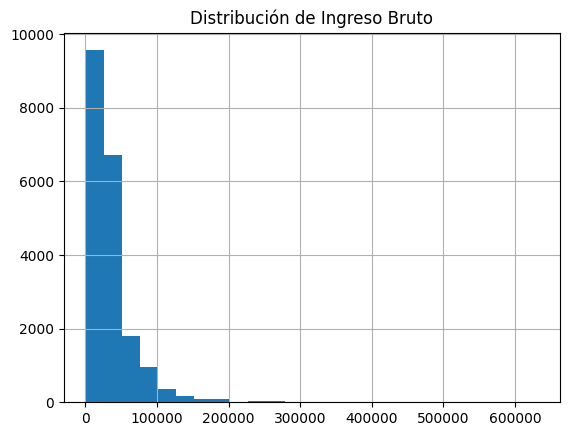

In [ ]:
# Distribución de ingresos
TablaFinal["IngresoBruto"].hist(bins=25)
plt.title("Distribución de Ingreso Bruto")
plt.show()

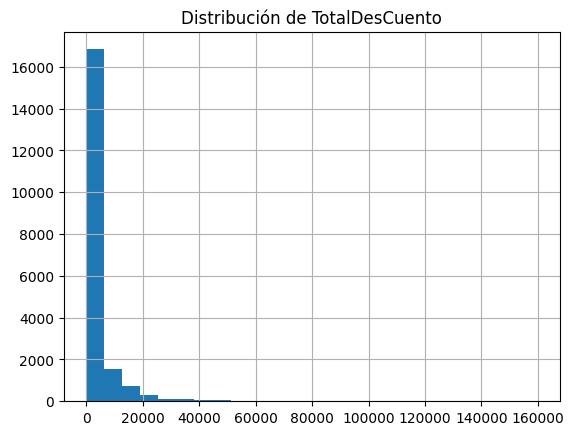

In [ ]:
# Deducion
TablaFinal["TotalDesCuento"].hist(bins=25)
plt.title("Distribución de TotalDesCuento")
plt.show()

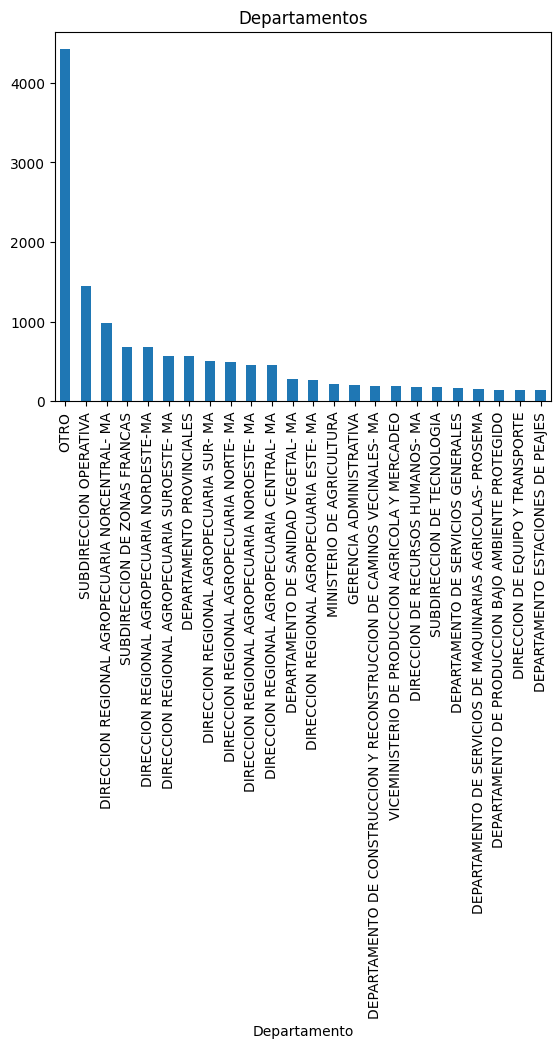

In [ ]:
# Departamento
TablaFinal["Departamento"].value_counts().plot(kind="bar")
plt.title("Departamentos")
plt.show()

In [ ]:
# Correlacion entre los datos numericos
numericos = ["IngresoBruto", "AFP", "SFS", "ISR", "OTROSDescuentos", "TotalDesCuento"]

TablaFinal[numericos].corr()

,IngresoBruto,AFP,SFS,ISR,OTROSDescuentos,TotalDesCuento
IngresoBruto,1.000000,0.940965,0.615683,0.903317,0.348719,0.957177
AFP,0.940965,1.000000,0.584460,0.845348,0.331923,0.913931
SFS,0.615683,0.584460,1.000000,0.398374,0.194182,0.645256
ISR,0.903317,0.845348,0.398374,1.000000,0.254537,0.955517
OTROSDescuentos,0.348719,0.331923,0.194182,0.254537,1.000000,0.284301
TotalDesCuento,0.957177,0.913931,0.645256,0.955517,0.284301,1.000000
